# Figures ICML 2026

In [1]:
from loss import * 
import numpy as np
import jax    
import jax.numpy as jnp
import matplotlib.pyplot as plt
import os
from omegaconf import OmegaConf
from metrics import *
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
def get_eigenvalues_jacobian(model, x):
    """Compute eigenvalues of the Jacobian of the model at point x."""
    J = jax.jacfwd(model)(x)
    eigvals = jnp.linalg.eigvals(J)
    return eigvals

In [3]:
jax.config.update("jax_enable_x64", True)

# Figure 1:

## Twobody

In [4]:
def compute_metrics(data, data_true=None):
    if data_true is not None:
        data["y_true"] = data_true.values
    data["y_true"] = data["y_true"].apply(lambda x: np.array(x))
    shape_true = data["y_true"][0].shape
    data["y_pred"] = data["y_pred"].apply(lambda x: np.array(x)[:shape_true[0], :shape_true[1]])
    data["L2"] = data.apply(lambda x: np.mean(np.array((x["y_true"] - x["y_pred"])**2)), axis=1)
    data["L2_relative_white"] = data.apply(lambda x: np.mean(np.sqrt(np.array((x["y_true"] - x["y_pred"])**2)/np.array(x["y_true"]**2))), axis=1)
    data["L2_over_time"] = data.apply(lambda x: np.array((x["y_true"] - x["y_pred"])**2).mean(axis=1), axis=1)
    data["L2_over_time_relative"] = data.apply(lambda x: x["L2_over_time"]/np.array(x["y_true"]**2).mean(axis=1), axis=1)
    data["L2_over_time_relative_white"] = data.apply(lambda x: np.sqrt(((x["y_true"]-x["y_pred"])**2).mean(axis=1)/((x["y_true"])**2).mean(axis=1)), axis=1)
    data["momentum_pred"] = data.apply(lambda x: np.array(x["y_pred"][:,0]*x["y_pred"][:,3] - x["y_pred"][:,1]*x["y_pred"][:,2]), axis=1)
    data["momentum_true"] = data.apply(lambda x: np.array(x["y_true"][:,0]*x["y_true"][:,3] - x["y_true"][:,1]*x["y_true"][:,2]), axis=1)
    data["momentum_over_time_relative_white"] = data.apply(lambda x: np.sqrt(((x["momentum_true"]-x["momentum_pred"])**2)/((x["momentum_true"])**2)), axis=1)

    return data

In [5]:
### TWOBODY: incomplete period 
dt_TB = 0.01
# Baselines
baseline_tb_002_8s = pd.read_json("data_exp/twobody_dt001_8s/none_aug_0.02_2_fc1i7jba/model_1.601e-10_longrun_dt_100.0_0.01.json").T
baseline_tb_002_8s = compute_metrics(baseline_tb_002_8s)

baseline_tb_005_8s = pd.read_json("data_exp/twobody_dt001_8s/none_aug_0.05_5_zvjsiwkz/model_1.742e-09_longrun_dt_100.0_0.01.json").T
baseline_tb_005_8s = compute_metrics(baseline_tb_005_8s)

baseline_tb_01_8s = pd.read_json("data_exp/twobody_dt001_8s/none_aug_0.1_8_tlrlhvdu/model_6.766e-09_longrun_dt_100.0_0.01.json").T
baseline_tb_01_8s = compute_metrics(baseline_tb_01_8s)

baseline_tb_02_8s = pd.read_json("data_exp/twobody_dt001_8s/none_aug_0.2_11_5prs1wa8/model_2.062e-08_longrun_dt_100.0_0.01.json").T
baseline_tb_02_8s = compute_metrics(baseline_tb_02_8s)

/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_23877/628380014.py:8: RuntimeWarning: invalid value encountered in divide
  data["L2_relative_white"] = data.apply(lambda x: np.mean(np.sqrt(np.array((x["y_true"] - x["y_pred"])**2)/np.array(x["y_true"]**2))), axis=1)
/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_23877/628380014.py:8: RuntimeWarning: invalid value encountered in divide
  data["L2_relative_white"] = data.apply(lambda x: np.mean(np.sqrt(np.array((x["y_true"] - x["y_pred"])**2)/np.array(x["y_true"]**2))), axis=1)
/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_23877/628380014.py:8: RuntimeWarning: invalid value encountered in divide
  data["L2_relative_white"] = data.apply(lambda x: np.mean(np.sqrt(np.array((x["y_true"] - x["y_pred"])**2)/np.array(x["y_true"]**2))), axis=1)
/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_23877/628380014.py:8: RuntimeWarning: invalid value encountered in divide
  data["L2_relative_white"] = data.a

In [21]:
baseline_tb_val_002 = np.load('/data_exp/twobody_dt001_8s/twobody0.02_val.npy', allow_pickle=True).item()

In [22]:
results = {}
states = jnp.array(baseline_tb_val_002['states'])[:,:,:] 
for k in range(states.shape[0]):
    results[k] = {
                    'y_true': np.array(states[k]).tolist(),
                }
baseline_tb_val_002 = pd.DataFrame(results).T

In [23]:
def define_df_from_npy(data_npy):
    results = {}
    states = jnp.array(data_npy)[:,:,:] 
    for k in range(states.shape[0]):
        results[k] = {
                        'y_pred': np.array(states[k]).tolist(),
                    }
    return pd.DataFrame(results).T

### Validation

In [24]:
### validation for optimal lambda
data_path = 'data_exp/twobody_dt001_8s'
dict_002_AD_sup_8s_val = {}
for folder in os.listdir(data_path):
    if "0.02" in folder:
        if "AD_sup" in folder:
            cfg = OmegaConf.load(os.path.join(data_path, folder, "config.yaml"))
            lambda_ = cfg.train.lambda0
            for file in os.listdir(os.path.join(data_path,folder)):
                if ".npy" in file:
                    data = np.load(os.path.join(data_path, folder, file), allow_pickle=True)
                    data = define_df_from_npy(data)
                    data["y_true"] = baseline_tb_val_002["y_true"]
                    data = compute_metrics(data)
                    dict_002_AD_sup_8s_val[lambda_] = data

/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_91738/628380014.py:8: RuntimeWarning: invalid value encountered in divide
  data["L2_relative_white"] = data.apply(lambda x: np.mean(np.sqrt(np.array((x["y_true"] - x["y_pred"])**2)/np.array(x["y_true"]**2))), axis=1)
/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_91738/628380014.py:8: RuntimeWarning: invalid value encountered in divide
  data["L2_relative_white"] = data.apply(lambda x: np.mean(np.sqrt(np.array((x["y_true"] - x["y_pred"])**2)/np.array(x["y_true"]**2))), axis=1)
/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_91738/628380014.py:8: RuntimeWarning: invalid value encountered in divide
  data["L2_relative_white"] = data.apply(lambda x: np.mean(np.sqrt(np.array((x["y_true"] - x["y_pred"])**2)/np.array(x["y_true"]**2))), axis=1)
/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_91738/628380014.py:8: RuntimeWarning: invalid value encountered in divide
  data["L2_relative_white"] = data.a

In [25]:
### validation for optimal lambda
data_path = 'data_exp/twobody_dt001_8s'
dict_002_FD_unsup_8s_val = {}
for folder in os.listdir(data_path):
    if "0.02" in folder:
        if "FD_unsup" in folder:
            cfg = OmegaConf.load(os.path.join(data_path, folder, "config.yaml"))
            lambda_ = cfg.train.lambda0
            for file in os.listdir(os.path.join(data_path,folder)):
                if ".npy" in file:
                    data = np.load(os.path.join(data_path, folder, file), allow_pickle=True)
                    data = define_df_from_npy(data)
                    data["y_true"] = baseline_tb_val_002["y_true"]
                    data = compute_metrics(data)
                    dict_002_FD_unsup_8s_val[lambda_] = data
            

/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_91738/628380014.py:8: RuntimeWarning: invalid value encountered in divide
  data["L2_relative_white"] = data.apply(lambda x: np.mean(np.sqrt(np.array((x["y_true"] - x["y_pred"])**2)/np.array(x["y_true"]**2))), axis=1)
/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_91738/628380014.py:8: RuntimeWarning: invalid value encountered in divide
  data["L2_relative_white"] = data.apply(lambda x: np.mean(np.sqrt(np.array((x["y_true"] - x["y_pred"])**2)/np.array(x["y_true"]**2))), axis=1)
/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_91738/628380014.py:8: RuntimeWarning: invalid value encountered in divide
  data["L2_relative_white"] = data.apply(lambda x: np.mean(np.sqrt(np.array((x["y_true"] - x["y_pred"])**2)/np.array(x["y_true"]**2))), axis=1)
/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_91738/628380014.py:8: RuntimeWarning: invalid value encountered in divide
  data["L2_relative_white"] = data.a

AD sup 1e-8            7.654912e-09
AD sup 1e-9            2.493943e-09
AD sup 1e-10           1.059725e-09
AD sup 1e-11           2.150642e-10
N=2, AD sup 5e-12      2.079570e-10
AD sup 1e-12           1.577540e-10
AD sup 5e-13           1.375664e-10
AD sup 1e-13           1.413840e-10
FD unsup 1e-9          1.564604e-10
FD unsup 1e-10         1.648778e-10
FD unsup 1e-11         1.555345e-10
FD unsup 5e-12         1.878257e-10
N=2, FD unsup 1e-12    2.059070e-10
FD unsup 5e-13         1.377115e-10
FD unsup 1e-13         1.435319e-10
dtype: float64

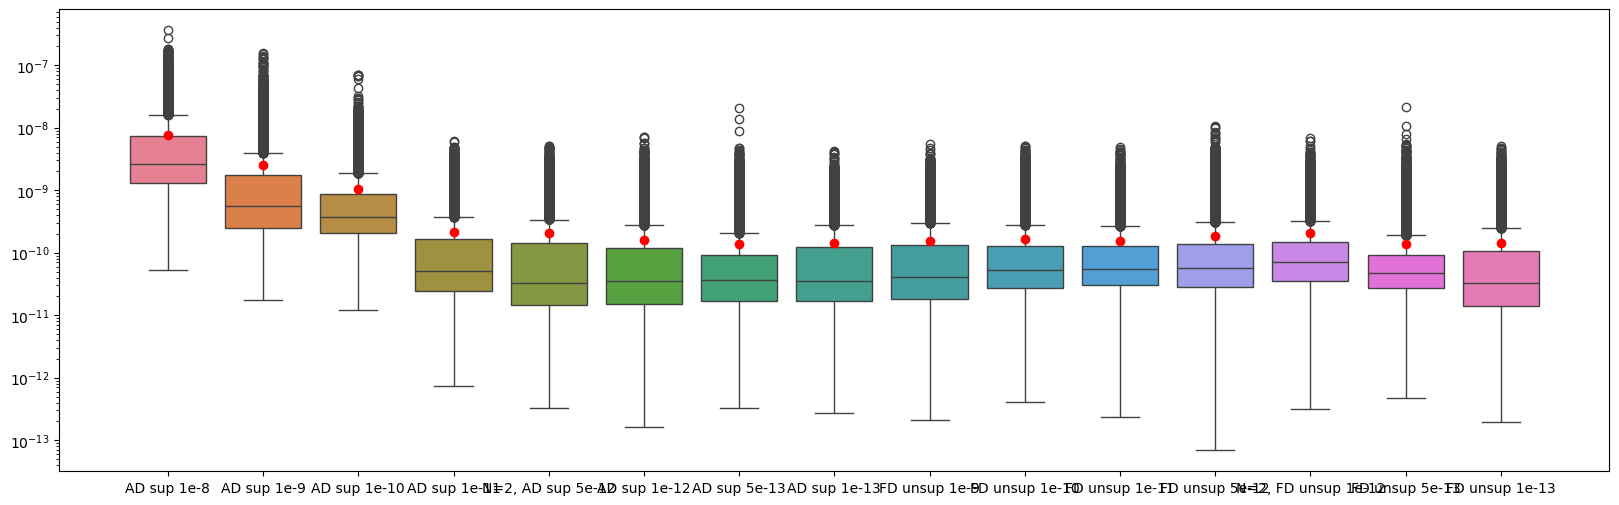

In [15]:
plt.figure(figsize=(20,6))
df = pd.DataFrame({
    #"N=2": baseline_tb_002_8s["L2"],
    #"N=5": baseline_tb_005_8s["L2"],
    #"N=10": baseline_tb_01_8s["L2"],
    "AD sup 1e-11": dict_002_AD_sup_8s_val[1e-11]["L2"],
    "N=2, AD sup 5e-12": dict_002_AD_sup_8s_val[5e-12]["L2"],
    "AD sup 1e-12": dict_002_AD_sup_8s_val[1e-12]["L2"],
    "AD sup 5e-13": dict_002_AD_sup_8s_val[5e-13]["L2"],
    "AD sup 1e-13": dict_002_AD_sup_8s_val[1e-13]["L2"],
    "FD unsup 1e-11": dict_002_FD_unsup_8s_val[1e-11]["L2"],
    "FD unsup 5e-12": dict_002_FD_unsup_8s_val[5e-12]["L2"],
    "N=2, FD unsup 1e-12": dict_002_FD_unsup_8s_val[1e-12]["L2"],
    "FD unsup 5e-13": dict_002_FD_unsup_8s_val[5e-13]["L2"],
    "FD unsup 1e-13": dict_002_FD_unsup_8s_val[1e-13]["L2"],
    })
sns.boxplot(df
)
means = df.mean()
# plot means as red dots
for i, mean in enumerate(means):
    plt.plot(i, mean, 'ro')
plt.yscale("log")
means

In [26]:
means_AD_tb = []
means_FD_tb = []
for lambda_ in [1e-11, 5e-12, 1e-12, 5e-13, 1e-13]:
    means_AD_tb.append(dict_002_AD_sup_8s_val[lambda_]["L2"].mean())

for lambda_ in [1e-11, 5e-12, 1e-12, 5e-13, 1e-13]:
    means_FD_tb.append(dict_002_FD_unsup_8s_val[lambda_]["L2"].mean())


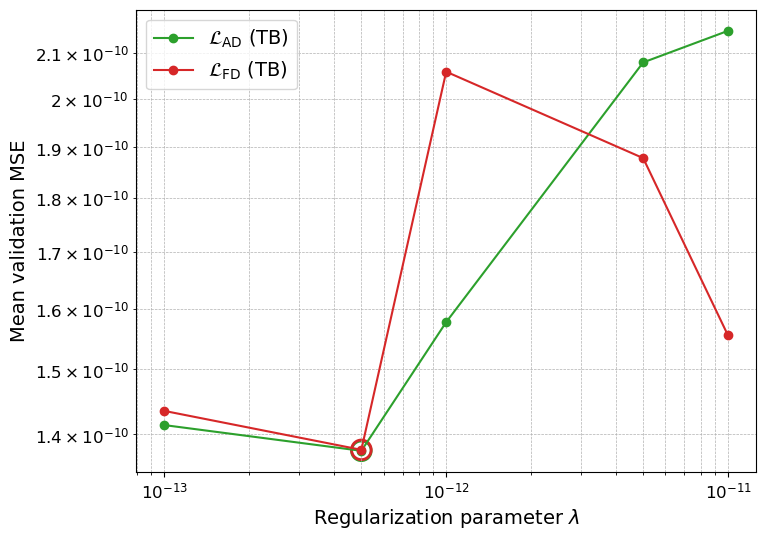

In [27]:
plt.figure(figsize=(8,6))
plt.plot([1e-11, 5e-12, 1e-12, 5e-13, 1e-13], means_AD_tb, label=r"$\mathcal{L}_{\text{AD}}$ (TB)", marker='o',color="C2")
plt.plot([1e-11, 5e-12, 1e-12, 5e-13, 1e-13], means_FD_tb, label=r"$\mathcal{L}_{\text{FD}}$ (TB)", marker='o', color="C3")
plt.scatter(5e-13, means_AD_tb[-2], s=200, facecolors='none', edgecolors='C2', linewidths=2)
plt.scatter(5e-13, means_FD_tb[-2], s=200, facecolors='none', edgecolors='C3', linewidths=2)
plt.xscale("log")
plt.yscale("log")
means_AD_tb
plt.legend(fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.xlabel("Regularization parameter $\lambda$", fontsize=14)
plt.ylabel("Mean validation MSE", fontsize=14)
plt.grid(True, which="both", ls="--", linewidth=0.5)

### Test

In [183]:
### results on test
data_path = "data_exp/twobody_dt001_8s"
dict_002_AD_sup_8s = {}
for folder in os.listdir(data_path):
    if "0.02" in folder:
        if "AD_sup" in folder:
            cfg = OmegaConf.load(os.path.join(data_path, folder, "config.yaml"))
            lambda_ = cfg.train.lambda0
            print(lambda_, os.path.join(data_path, folder))
            for file in os.listdir(os.path.join(data_path,folder)):
                if ".json" in file:
                    if not "val" in file:
                        data = pd.read_json(os.path.join(data_path, folder, file)).T
                        data["y_true"] = baseline_tb_002_8s["y_true"]
                        data = compute_metrics(data)
                        dict_002_AD_sup_8s[lambda_] = data
            

1e-07 data_exp/twobody_dt001_8s/none_AD_sup_aug_0.02_18_22z4vgj5
5e-08 data_exp/twobody_dt001_8s/none_AD_sup_aug_0.02_19_8tfhxf81
1e-09 data_exp/twobody_dt001_8s/none_AD_sup_aug_0.02_17_maia1avr


/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_45953/1273360162.py:8: RuntimeWarning: invalid value encountered in divide
  data["L2_relative_white"] = data.apply(lambda x: np.mean(np.sqrt(np.array((x["y_true"] - x["y_pred"])**2)/np.array(x["y_true"]**2))), axis=1)
/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_45953/1273360162.py:25: RuntimeWarning: overflow encountered in square
  data["momentum_over_time_relative_white"] = data.apply(lambda x: np.sqrt(((x["momentum_true"]-x["momentum_pred"])**2)/((x["momentum_true"])**2)), axis=1)
/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_45953/1273360162.py:25: RuntimeWarning: overflow encountered in divide
  data["momentum_over_time_relative_white"] = data.apply(lambda x: np.sqrt(((x["momentum_true"]-x["momentum_pred"])**2)/((x["momentum_true"])**2)), axis=1)


1e-10 data_exp/twobody_dt001_8s/none_AD_sup_aug_0.02_20_ejmzkddo


/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_45953/1273360162.py:8: RuntimeWarning: invalid value encountered in divide
  data["L2_relative_white"] = data.apply(lambda x: np.mean(np.sqrt(np.array((x["y_true"] - x["y_pred"])**2)/np.array(x["y_true"]**2))), axis=1)


1e-08 data_exp/twobody_dt001_8s/none_AD_sup_aug_0.02_16_wi47ujol


...

/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_45953/1273360162.py:8: RuntimeWarning: invalid value encountered in divide
  data["L2_relative_white"] = data.apply(lambda x: np.mean(np.sqrt(np.array((x["y_true"] - x["y_pred"])**2)/np.array(x["y_true"]**2))), axis=1)


5e-13 data_exp/twobody_dt001_8s/none_AD_sup_aug_0.02_33_sujabr6g


/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_45953/1273360162.py:8: RuntimeWarning: invalid value encountered in divide
  data["L2_relative_white"] = data.apply(lambda x: np.mean(np.sqrt(np.array((x["y_true"] - x["y_pred"])**2)/np.array(x["y_true"]**2))), axis=1)


5e-12 data_exp/twobody_dt001_8s/none_AD_sup_aug_0.02_24_hgbrfe7m


/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_45953/1273360162.py:8: RuntimeWarning: invalid value encountered in divide
  data["L2_relative_white"] = data.apply(lambda x: np.mean(np.sqrt(np.array((x["y_true"] - x["y_pred"])**2)/np.array(x["y_true"]**2))), axis=1)


In [184]:
data_path = "data_exp/twobody_dt001_8s"
dict_002_FD_unsup_8s = {}
for folder in os.listdir(data_path):
    if "0.02" in folder:
        if "FD_unsup" in folder:
            cfg = OmegaConf.load(os.path.join(data_path, folder, "config.yaml"))
            lambda_ = cfg.train.lambda0
            print(lambda_, os.path.join(data_path, folder))
            for file in os.listdir(os.path.join(data_path,folder)):
                if ".json" in file:
                    if not "val" in file:
                        data = pd.read_json(os.path.join(data_path, folder, file)).T
                        data["y_true"] = baseline_tb_002_8s["y_true"]
                        data = compute_metrics(data)
                        dict_002_FD_unsup_8s[lambda_] = data
            

5e-12 data_exp/twobody_dt001_8s/none_FD_unsup_aug_0.02_30_hwdn8fj0


/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_45953/1273360162.py:8: RuntimeWarning: invalid value encountered in divide
  data["L2_relative_white"] = data.apply(lambda x: np.mean(np.sqrt(np.array((x["y_true"] - x["y_pred"])**2)/np.array(x["y_true"]**2))), axis=1)


1e-13 data_exp/twobody_dt001_8s/none_FD_unsup_aug_0.02_29_c9iqyrad


/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_45953/1273360162.py:8: RuntimeWarning: invalid value encountered in divide
  data["L2_relative_white"] = data.apply(lambda x: np.mean(np.sqrt(np.array((x["y_true"] - x["y_pred"])**2)/np.array(x["y_true"]**2))), axis=1)


1e-09 data_exp/twobody_dt001_8s/none_FD_unsup_aug_0.02_25_5e579mhv


...

/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_45953/1273360162.py:8: RuntimeWarning: invalid value encountered in divide
  data["L2_relative_white"] = data.apply(lambda x: np.mean(np.sqrt(np.array((x["y_true"] - x["y_pred"])**2)/np.array(x["y_true"]**2))), axis=1)


1e-11 data_exp/twobody_dt001_8s/none_FD_unsup_aug_0.02_27_3rcq5t6i


/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_45953/1273360162.py:8: RuntimeWarning: invalid value encountered in divide
  data["L2_relative_white"] = data.apply(lambda x: np.mean(np.sqrt(np.array((x["y_true"] - x["y_pred"])**2)/np.array(x["y_true"]**2))), axis=1)


1e-12 data_exp/twobody_dt001_8s/none_FD_unsup_aug_0.02_28_puqolrug


/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_45953/1273360162.py:8: RuntimeWarning: invalid value encountered in divide
  data["L2_relative_white"] = data.apply(lambda x: np.mean(np.sqrt(np.array((x["y_true"] - x["y_pred"])**2)/np.array(x["y_true"]**2))), axis=1)


Text(0.5, 0, 'Model')

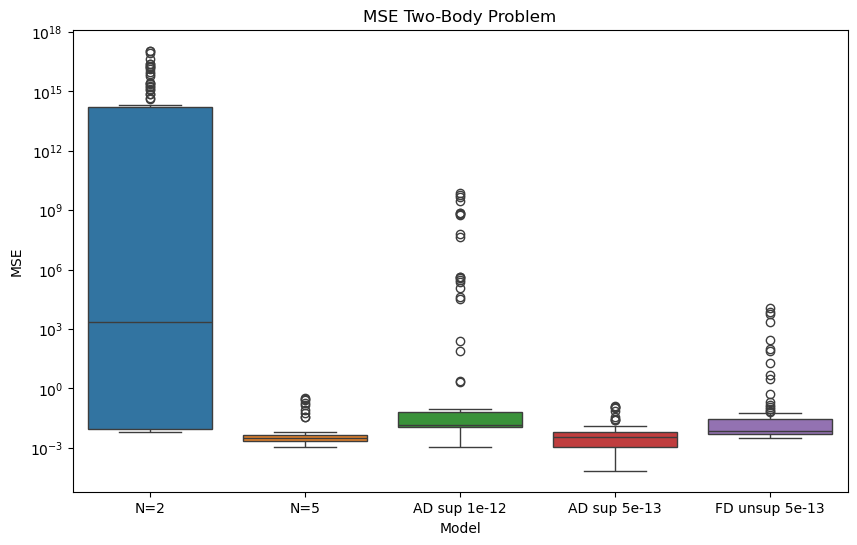

In [29]:
plt.figure(figsize=(10,6))
sns.boxplot(pd.DataFrame({
    "N=2": baseline_tb_002_8s["L2"],
    "N=5": baseline_tb_005_8s["L2"],
    #"N=2 boost": baseline_tb_002_8s_boost["L2"], 
    #"N=5 boost": baseline_tb_005_8s_boost["L2"],
    #"N=10": baseline_tb_01_8s["L2"],
    #"AD sup 1e-8": dict_002_AD_sup_8s[1e-8]["L2"],
    #"AD sup 1e-9": dict_002_AD_sup_8s[1e-9]["L2"],
    #"AD sup 1e-10": dict_002_AD_sup_8s[1e-10]["L2"],
    #"AD sup 1e-11": dict_002_AD_sup_8s[1e-11]["L2"],
    #"N=2, AD sup 5e-12": dict_002_AD_sup_8s[5e-12]["L2"],
    #"AD sup 1e-12": dict_002_AD_sup_8s[1e-12]["L2"],
    "AD sup 5e-13": dict_002_AD_sup_8s[5e-13]["L2"],
    #"AD sup 1e-13": dict_002_AD_sup_8s[1e-13]["L2"],
    #"FD unsup 1e-11": dict_002_FD_unsup_8s[1e-11]["L2"],
    #"FD unsup 5e-12": dict_002_FD_unsup_8s[5e-12]["L2"],
    #"N=2, FD unsup 1e-12": dict_002_FD_unsup_8s[1e-12]["L2"],
    "FD unsup 5e-13": dict_002_FD_unsup_8s[5e-13]["L2"],
    #"FD unsup 1e-13": dict_002_FD_unsup_8s[1e-13]["L2"],
    })
)
plt.yscale("log")
plt.title("MSE Two-Body Problem")
plt.yscale("log")
plt.ylabel("MSE")
plt.xlabel("Model")

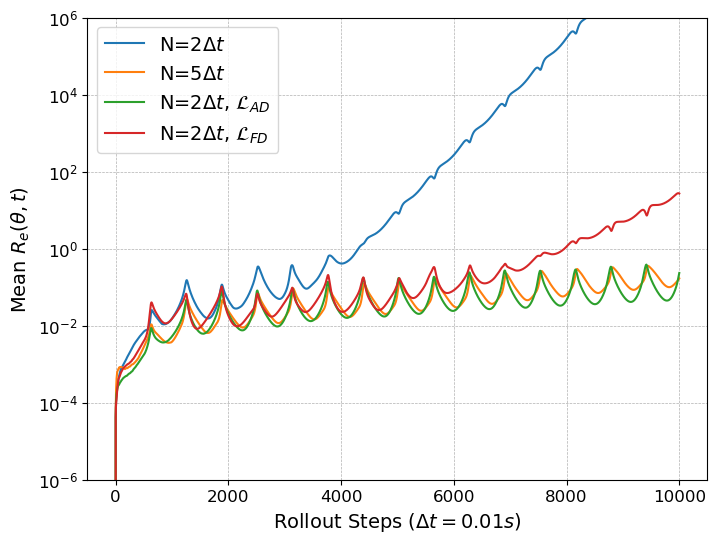

In [185]:
plt.figure(figsize=(8,6))
plt.plot(baseline_tb_002_8s["L2_over_time_relative_white"].mean(), label="N=2$\Delta t$")
plt.plot(baseline_tb_005_8s["L2_over_time_relative_white"].mean(), label="N=5$\Delta t$")
plt.plot(dict_002_AD_sup_8s[5e-13]["L2_over_time_relative_white"].mean(), label="N=2$\Delta t$, $\mathcal{L}_{AD}$", color="C2")
plt.plot(dict_002_FD_unsup_8s[5e-13]["L2_over_time_relative_white"].mean(), label="N=2$\Delta t$, $\mathcal{L}_{FD}$", color="C3")
plt.yscale("log")
plt.legend(fontsize=14)
plt.ylim(1e-6,1e6)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.ylabel(r"Mean $R_e(\theta,t)$", fontsize=14)
plt.xlabel("Rollout Steps ($\Delta t=0.01s$)", fontsize=14)
plt.grid(True, which="both", ls="--", linewidth=0.5)

([0, 1, 2, 3],
 [Text(0, 0, 'N=2$\\Delta t$'),
  Text(1, 0, 'N=5$\\Delta t$'),
  Text(2, 0, 'N=2$\\Delta t$, $\\mathcal{L}_{AD}$'),
  Text(3, 0, 'N=2$\\Delta t$, $\\mathcal{L}_{FD}$')])

<Figure size 800x600 with 0 Axes>

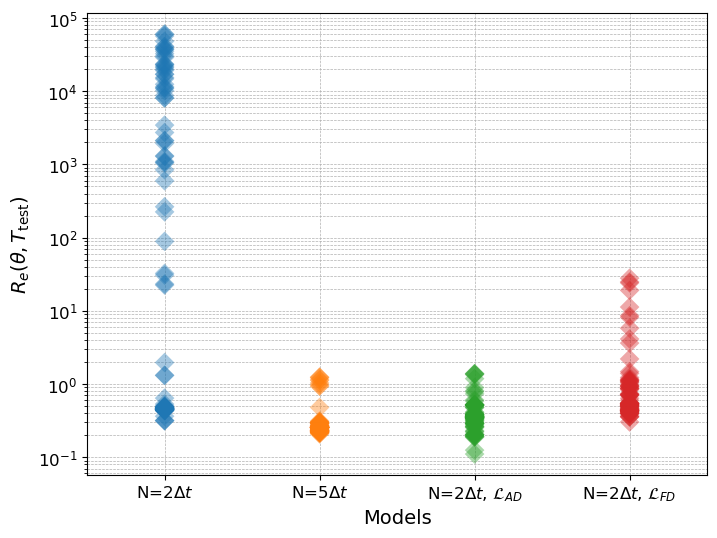

In [186]:
plt.figure(figsize=(8,6))
df = pd.DataFrame({
    "N=2$\Delta t$": np.sqrt(baseline_tb_002_8s["L2_over_time_relative_white"].apply(lambda x: x[-1])),
    "N=5$\Delta t$": np.sqrt(baseline_tb_005_8s["L2_over_time_relative_white"].apply(lambda x: x[-1])),
    "N=2$\Delta t$, $\mathcal{L}_{AD}$": np.sqrt(dict_002_AD_sup_8s[5e-13]["L2_over_time_relative_white"].apply(lambda x: x[-1])),
    "N=2$\Delta t$, $\mathcal{L}_{FD}$": np.sqrt(dict_002_FD_unsup_8s[5e-13]["L2_over_time_relative_white"].apply(lambda x: x[-1])),
})
fig, ax = plt.subplots(1,figsize=(8,6))

sns.stripplot(
    df,
    jitter=False,
    alpha=0.4,
    s=10,
    marker="D",
    ax=ax,
    )

plt.tick_params(axis='both', which='major', labelsize=12)
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.yscale("log")
plt.ylabel(r"$R_e(\theta, T_{\text{test}})$", fontsize=14)
plt.xlabel("Models",fontsize=14 )
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.xticks()


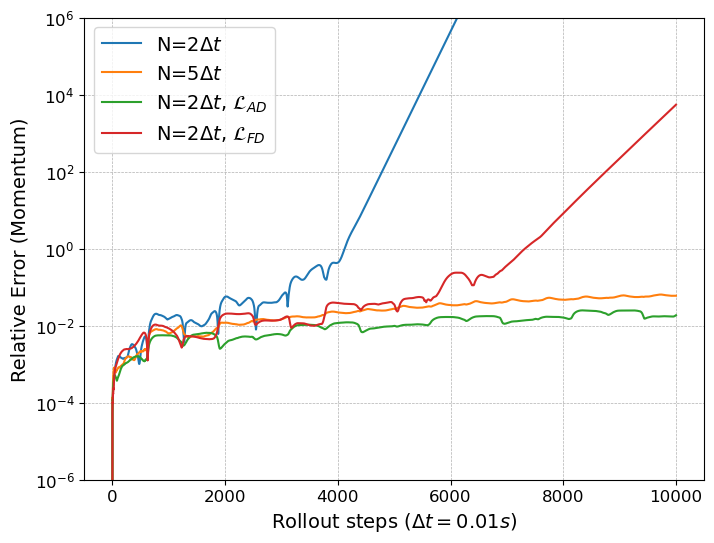

In [226]:
# fix size of labels
plt.figure(figsize=(8,6))
plt.plot(baseline_tb_002_8s["momentum_over_time_relative_white"].mean(), label="N=2$\Delta t$")
plt.plot(baseline_tb_005_8s["momentum_over_time_relative_white"].mean(), label="N=5$\Delta t$")
plt.plot(dict_002_AD_sup_8s[5e-13]["momentum_over_time_relative_white"].mean(), label="N=2$\Delta t$, $\mathcal{L}_{AD}$")
plt.plot(dict_002_FD_unsup_8s[5e-13]["momentum_over_time_relative_white"].mean(), label="N=2$\Delta t$, $\mathcal{L}_{FD}$")
plt.yscale("log")
plt.legend(loc="upper left", fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.ylim(1e-6,1e6)
plt.ylabel("Relative Error (Momentum)", fontsize=14)
plt.xlabel("Rollout steps ($\Delta t=0.01s$)", fontsize=14)
#plt.title("Twobody problem")
plt.grid(True, which="both", ls="--", linewidth=0.5)

([0, 1, 2, 3],
 [Text(0, 0, 'N=2$\\Delta t$'),
  Text(1, 0, 'N=5$\\Delta t$'),
  Text(2, 0, 'N=2$\\Delta t$, $\\mathcal{L}_{AD}$'),
  Text(3, 0, 'N=2$\\Delta t$, $\\mathcal{L}_{FD}$')])

<Figure size 800x600 with 0 Axes>

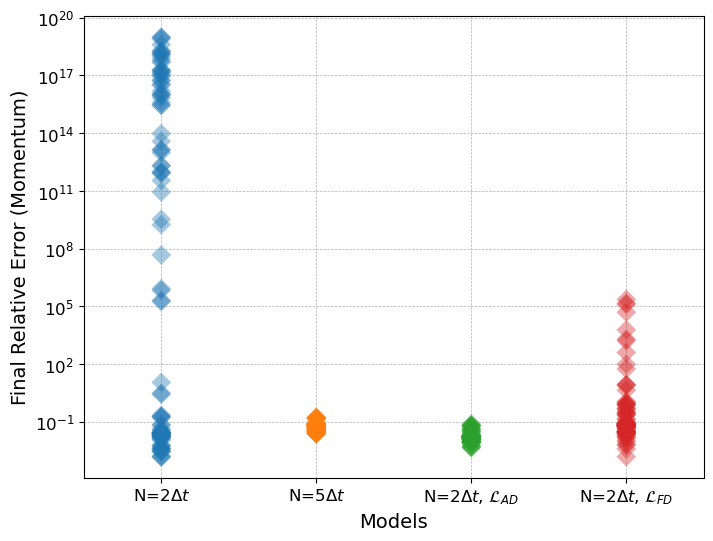

In [49]:
plt.figure(figsize=(8,6))
df = pd.DataFrame({
    "N=2$\Delta t$": baseline_tb_002_8s["momentum_over_time_relative_white"].apply(lambda x: x[-1]),
    "N=5$\Delta t$": baseline_tb_005_8s["momentum_over_time_relative_white"].apply(lambda x: x[-1]),
    "N=2$\Delta t$, $\mathcal{L}_{AD}$": dict_002_AD_sup_8s[5e-13]["momentum_over_time_relative_white"].apply(lambda x: x[-1]),
    "N=2$\Delta t$, $\mathcal{L}_{FD}$": dict_002_FD_unsup_8s[5e-13]["momentum_over_time_relative_white"].apply(lambda x: x[-1]),
})
fig, ax = plt.subplots(1,figsize=(8,6))
sns.stripplot(
    df,
    jitter=False,
    alpha=0.4,
    s=10,
    marker="D",
    ax=ax,
    )
plt.yscale("log")
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.ylabel(r"Final Relative Error (Momentum)", fontsize=14)
plt.xlabel("Models", fontsize=14)
plt.grid(True, which="major", ls="--", linewidth=0.5)
plt.xticks()
#plt.minorticks_off()


10


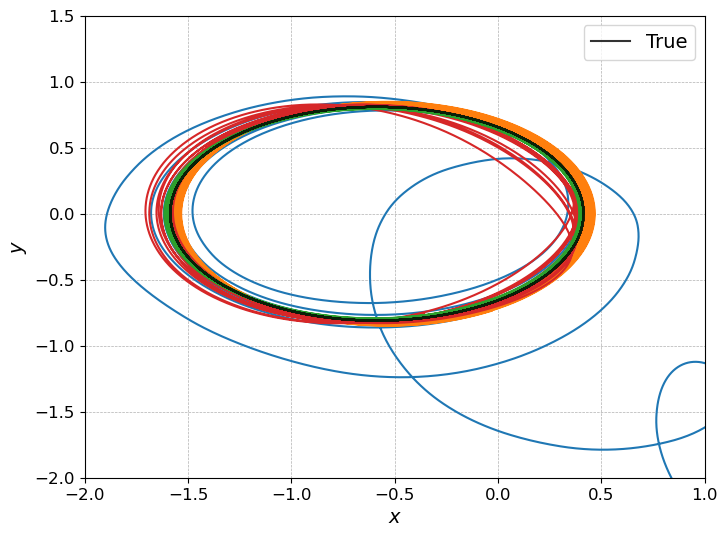

In [227]:
# trajectory
plt.figure(figsize=(8,6))
#k= baseline_tb_002_8s["L2"].idxmax()
k = (dict_002_AD_sup_8s[5e-13]["L2_over_time"].apply(lambda x: x[-1]) / baseline_tb_002_8s["L2_over_time"].apply(lambda x: x[-1])).idxmin()
k = 10
time=-1
plt.plot(baseline_tb_002_8s["y_pred"][k][:time,0], baseline_tb_002_8s["y_pred"][k][:time,1])
plt.plot(baseline_tb_005_8s["y_pred"][k][:,0], baseline_tb_005_8s["y_pred"][k][:,1])
plt.plot(dict_002_FD_unsup_8s[5e-13]["y_pred"][k][:,0], dict_002_FD_unsup_8s[1e-12]["y_pred"][k][:,1], color="C3")
plt.plot(dict_002_AD_sup_8s[5e-13]["y_pred"][k][:,0], dict_002_AD_sup_8s[5e-13]["y_pred"][k][:,1], color="C2")

plt.plot(baseline_tb_002_8s["y_true"][k][:,0], baseline_tb_002_8s["y_true"][k][:,1], label="True", color="black", alpha=0.8)
plt.xlabel("$x$", fontsize=14)
plt.ylabel("$y$", fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.ylim(-2,1.5)
plt.xlim(-2, 1)
plt.legend(loc="upper right", fontsize=14)
#plt.title("Twobody problem - Trajectory best improvement N=2 $\mathcal{L}_{AD}$")
plt.grid(True, which="both", ls="--", linewidth=0.5)
print(k)

## Rigid body

In [187]:
dt_RB = 0.1

In [28]:
def compute_metrics_rigidbody(data, data_true=None):
    if data_true is not None:
        data["y_true"] = data_true.values
    data["y_true"] = data["y_true"].apply(lambda x: np.array(x))
    shape_true = data["y_true"][0].shape
    data["y_pred"] = data["y_pred"].apply(lambda x: np.array(x)[:shape_true[0], :shape_true[1]])
    data["L2"] = data.apply(lambda x: np.mean(np.array((x["y_true"] - x["y_pred"])**2)), axis=1)
    data["L2_relative"] = data.apply(lambda x: x["L2"]/np.mean(np.array(x["y_true"]**2)), axis=1)
    data["L2_over_time"] = data.apply(lambda x: np.array((x["y_true"] - x["y_pred"])**2).mean(axis=1), axis=1)
    data["L2_over_time_relative"] = data.apply(lambda x: x["L2_over_time"]/np.array(x["y_true"]**2).mean(axis=1), axis=1)
    data["L2_over_time_relative_white"] = data.apply(lambda x: np.sqrt(((x["y_true"]-x["y_pred"])**2).mean(axis=1)/((x["y_true"])**2).mean(axis=1)), axis=1)
    data["holo_pred"] = data.apply(lambda x: np.array(x["y_pred"][:,0]**2+ x["y_pred"][:,1]**2 + x["y_pred"][:,2]**2), axis=1)
    data["holo_true"] = data.apply(lambda x: np.array(x["y_true"][:,0]**2+ x["y_true"][:,1]**2 + x["y_true"][:,2]**2), axis=1)
    data["holo_over_time_relative_white"] = data.apply(lambda x: np.sqrt(((x["holo_true"]-x["holo_pred"])**2)/((x["holo_true"])**2)), axis=1)
    return data

In [29]:
baseline_rigidbody_05 = pd.read_json('data_exp/rigidbody/none_aug_0.5_5_y3af0b13/model_8.025e-09_longrun_dt_800.0_0.1.json').T
baseline_rigidbody_05 = compute_metrics_rigidbody(baseline_rigidbody_05)

baseline_rigidbody_1 = pd.read_json('data_exp/rigidbody/none_aug_1.0_4_6dmux55q/model_2.575e-08_longrun_dt_800.0_0.1.json').T
baseline_rigidbody_1 = compute_metrics_rigidbody(baseline_rigidbody_1)

In [30]:
baseline_rigidbody_val_05 = np.load('data_exp/rigidbody/rigidbody0.5_val.npy', allow_pickle=True).item()

In [34]:
### validation for optimal lambda
data_path = '/data_exp/rigidbody'
dict_05_AD_sup_RB_val = {}
for folder in os.listdir(data_path):
    if "0.5" in folder:
        if "AD_sup" in folder:
            cfg = OmegaConf.load(os.path.join(data_path, folder, "config.yaml"))
            lambda_ = cfg.train.lambda0
            for file in os.listdir(os.path.join(data_path,folder)):
                if ".npy" in file:
                        data = np.load(os.path.join(data_path, folder, file), allow_pickle=True)
                        data = define_df_from_npy(data)
                        data["y_true"] = baseline_rigidbody_val_05["y_true"]
                        data = compute_metrics_rigidbody(data)
                        dict_05_AD_sup_RB_val[lambda_] = data
            

In [36]:
### validation for optimal lambda
data_path = 'data_exp/rigidbody'
dict_05_FD_unsup_RB_val = {}
for folder in os.listdir(data_path):
    if "0.5" in folder:
        if "FD_unsup" in folder:
            cfg = OmegaConf.load(os.path.join(data_path, folder, "config.yaml"))
            lambda_ = cfg.train.lambda0
            for file in os.listdir(os.path.join(data_path,folder)):
                if ".npy" in file:
                    data = np.load(os.path.join(data_path, folder, file), allow_pickle=True)
                    data = define_df_from_npy(data)
                    data["y_true"] = baseline_rigidbody_val_05["y_true"]
                    data = compute_metrics_rigidbody(data)
                    dict_05_FD_unsup_RB_val[lambda_] = data
            

In [76]:
means_AD_rb = []
means_FD_rb = []
for lambda_ in [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]:
    means_AD_rb.append(dict_05_AD_sup_RB_val[lambda_]["L2"].mean())

for lambda_ in [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]:
    means_FD_rb.append(dict_05_FD_unsup_RB_val[lambda_]["L2"].mean())


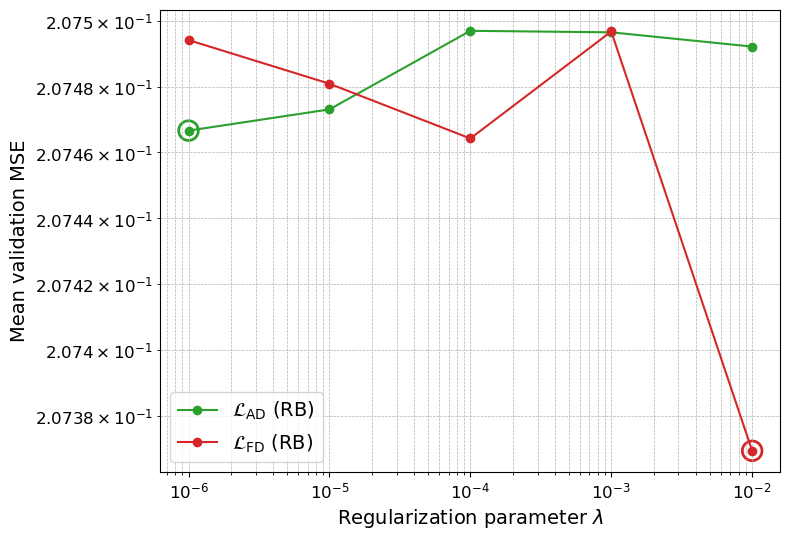

In [201]:
plt.figure(figsize=(8,6))
plt.plot([1e-2, 1e-3, 1e-4, 1e-5, 1e-6], means_AD_rb, label=r"$\mathcal{L}_{\text{AD}}$ (RB)", marker='o',color="C2")
plt.plot([1e-2, 1e-3, 1e-4, 1e-5, 1e-6], means_FD_rb, label=r"$\mathcal{L}_{\text{FD}}$ (RB)", marker='o', color="C3")
plt.scatter(1e-6, means_AD_rb[-1], s=200, facecolors='none', edgecolors='C2', linewidths=2)
plt.scatter(1e-2, means_FD_rb[0], s=200, facecolors='none', edgecolors='C3', linewidths=2)
plt.xscale("log")
plt.yscale("log")
plt.legend(fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.xlabel("Regularization parameter $\lambda$", fontsize=14)
plt.ylabel("Mean validation MSE", fontsize=14)
plt.grid(True, which="both", ls="--", linewidth=0.5)

### Results on test

In [37]:
### final results on test
data_path = "/data_exp/rigidbody"
dict_05_AD_sup_RB = {}
for folder in os.listdir(data_path):
    if "0.5" in folder:
        if "AD_sup" in folder:
            cfg = OmegaConf.load(os.path.join(data_path, folder, "config.yaml"))
            lambda_ = cfg.train.lambda0
            if lambda_ not in [0.01]:
                for file in os.listdir(os.path.join(data_path,folder)):
                    if ".json" in file:
                        if "val" not in file:
                            data = pd.read_json(os.path.join(data_path, folder, file)).T
                            data["y_true"] = baseline_rigidbody_05["y_true"]
                            data = compute_metrics_rigidbody(data)
                            dict_05_AD_sup_RB[lambda_] = data
                

In [38]:
data_path = "data_exp/rigidbody"
dict_05_FD_unsup_RB = {}
for folder in os.listdir(data_path):
    if "0.5" in folder:
        if "FD_unsup" in folder:
            cfg = OmegaConf.load(os.path.join(data_path, folder, "config.yaml"))
            lambda_ = cfg.train.lambda0
            for file in os.listdir(os.path.join(data_path,folder)):
                if ".json" in file:
                    if "val" not in file:
                        data = pd.read_json(os.path.join(data_path, folder, file)).T
                        data["y_true"] = baseline_rigidbody_05["y_true"]
                        data = compute_metrics_rigidbody(data)
                        dict_05_FD_unsup_RB[lambda_] = data
            

Text(0.5, 1.0, 'MSE Rigidbody')

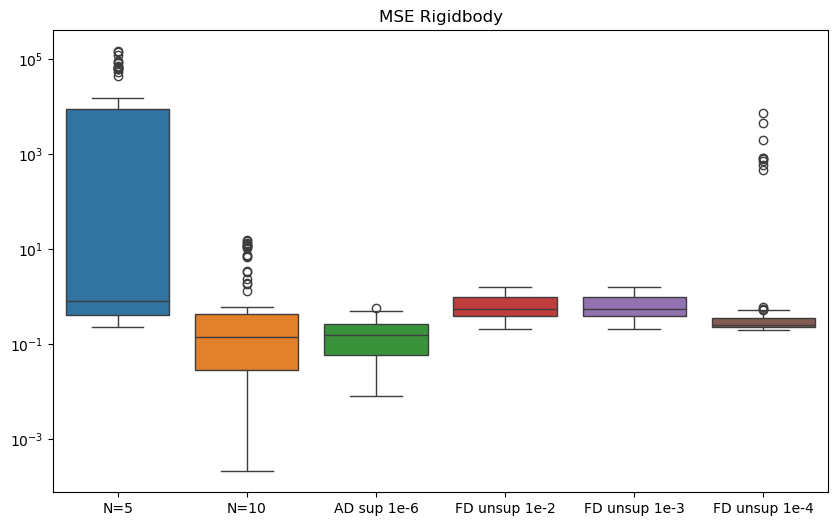

In [75]:
plt.figure(figsize=(10,6))
sns.boxplot(pd.DataFrame({
    #"N=1": baseline_rigidbody_01["L2"],
    "N=5": baseline_rigidbody_05["L2"],
    "N=10": baseline_rigidbody_1["L2"],
    #"N=5" +"\n" +"$\mathcal{L}_{AD}$, $\lambda$=0.001": dict_05_AD_sup_RB[1e-3]["L2"],
    #"N=5"+"\n" +"$\mathcal{L}_{AD}$, $\lambda$=0.0001": dict_05_AD_sup_RB[1e-4]["L2"],
    #"AD sup 1e-5": dict_05_AD_sup_RB[1e-5]["L2"],
    "AD sup 1e-6": dict_05_AD_sup_RB[1e-6]["L2"],
    "FD unsup 1e-2": dict_05_FD_unsup_RB[1e-3]["L2"],
    "FD unsup 1e-3": dict_05_FD_unsup_RB[1e-3]["L2"],
    "FD unsup 1e-4": dict_05_FD_unsup_RB[1e-4]["L2"],
    # "FD unsup 5e-5": dict_05_FD_unsup_RB[5e-5]["L2"],
    # "FD unsup 1e-5": dict_05_FD_unsup_RB[1e-5]["L2"],
    # "FD unsup 5e-6": dict_05_FD_unsup_RB[5e-6]["L2"],
    # "FD unsup 1e-6": dict_05_FD_unsup_RB[1e-6]["L2"],
    })
)
plt.yscale("log")
plt.title("MSE Rigidbody")

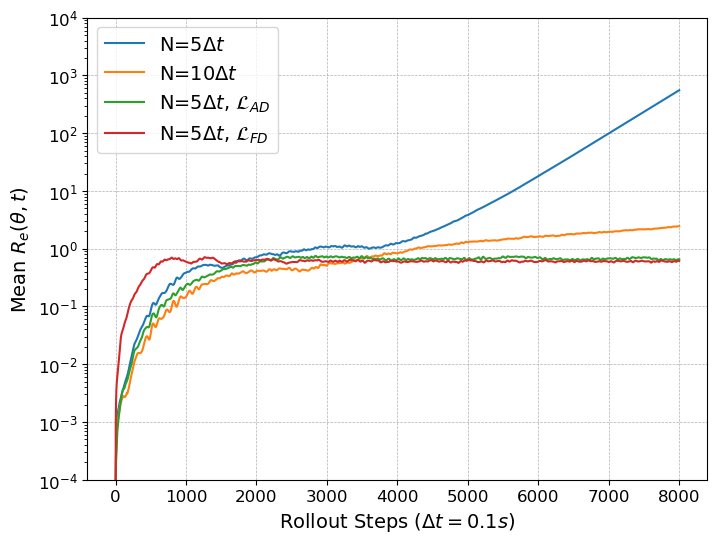

In [192]:
plt.figure(figsize=(8,6))
plt.plot(baseline_rigidbody_05["L2_over_time_relative_white"].mean(), label="N=5$\Delta t$")
plt.plot(baseline_rigidbody_1["L2_over_time_relative_white"].mean(), label="N=10$\Delta t$")
plt.plot(dict_05_AD_sup_RB[1e-6]["L2_over_time_relative_white"].mean(), label="N=5$\Delta t$, $\mathcal{L}_{AD}$")
plt.plot(dict_05_FD_unsup_RB[1e-2]["L2_over_time_relative_white"].mean(), label="N=5$\Delta t$, $\mathcal{L}_{FD}$")
plt.yscale("log")
plt.ylim(1e-4, 1e4)
plt.legend(fontsize=14)
plt.ylabel(r"Mean $R_e(\theta,t)$", fontsize=14)
plt.xlabel("Rollout Steps ($\Delta t = 0.1s$)", fontsize=14)


plt.grid(True, which="major", ls="--", linewidth=0.5)
plt.tick_params(axis='both', which='major', labelsize=12)




(0.01, 100000.0)

<Figure size 800x600 with 0 Axes>

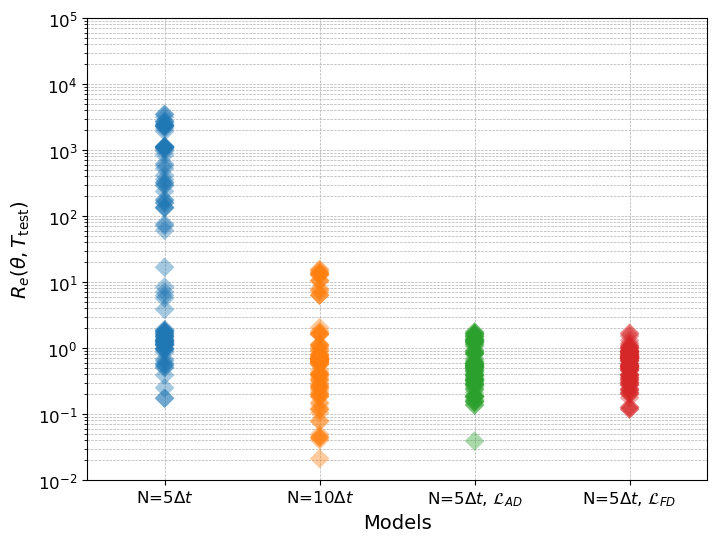

In [193]:
plt.figure(figsize=(8,6))
df = pd.DataFrame({
    "N=5$\Delta t$": baseline_rigidbody_05["L2_over_time_relative_white"].apply(lambda x: x[-1]),
    "N=10$\Delta t$": baseline_rigidbody_1["L2_over_time_relative_white"].apply(lambda x: x[-1]),
    "N=5$\Delta t$, $\mathcal{L}_{AD}$": dict_05_AD_sup_RB[1e-6]["L2_over_time_relative_white"].apply(lambda x: x[-1]),
    "N=5$\Delta t$, $\mathcal{L}_{FD}$": dict_05_FD_unsup_RB[1e-2]["L2_over_time_relative_white"].apply(lambda x: x[-1]),
})
fig, ax = plt.subplots(1,figsize=(8,6))
sns.stripplot(
    df,
    jitter=False,
    alpha=0.4,
    s=10,
    marker="D",
    ax=ax,
)
plt.yscale("log")
plt.ylabel(r"$R_e(\theta, T_{\text{test}})$", fontsize=14)
plt.xlabel("Models", fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.ylim(1e-2, 1e5)

(0.0001, 10000.0)

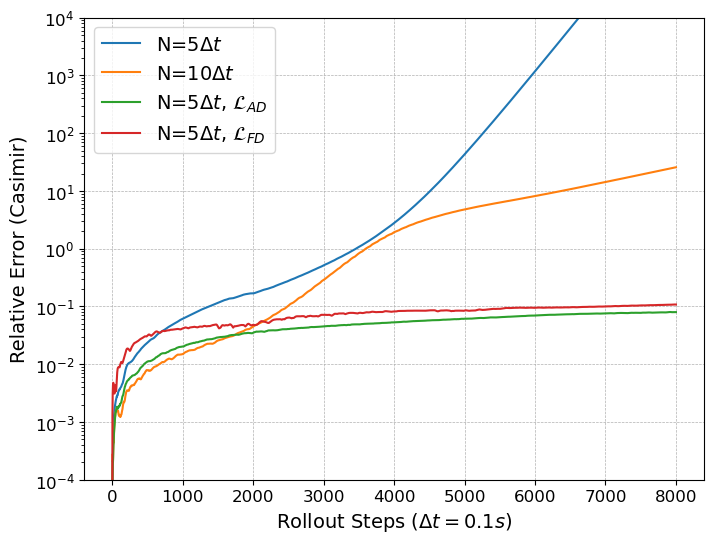

In [229]:

plt.figure(figsize=(8,6))
plt.plot(baseline_rigidbody_05["holo_over_time_relative_white"].mean(), label="N=5$\Delta t$")
plt.plot(baseline_rigidbody_1["holo_over_time_relative_white"].mean(), label="N=10$\Delta t$")
plt.plot(dict_05_AD_sup_RB[1e-6]["holo_over_time_relative_white"].mean(), label="N=5$\Delta t$, $\mathcal{L}_{AD}$")
plt.plot(dict_05_FD_unsup_RB[1e-2]["holo_over_time_relative_white"].mean(), label="N=5$\Delta t$, $\mathcal{L}_{FD}$")
plt.yscale("log")
plt.legend(fontsize=14)
plt.grid(True, which="major", ls="--", linewidth=0.5)
#plt.title("Rigidbody")
plt.ylabel("Relative Error (Casimir)", fontsize=14)
plt.xlabel("Rollout Steps ($\Delta t = 0.1s$)", fontsize=14)

plt.tick_params(axis='both', which='major', labelsize=12)
plt.tick_params(axis='both', which='minor', labelsize=12)

plt.ylim(1e-4, 1e4)



<Figure size 800x600 with 0 Axes>

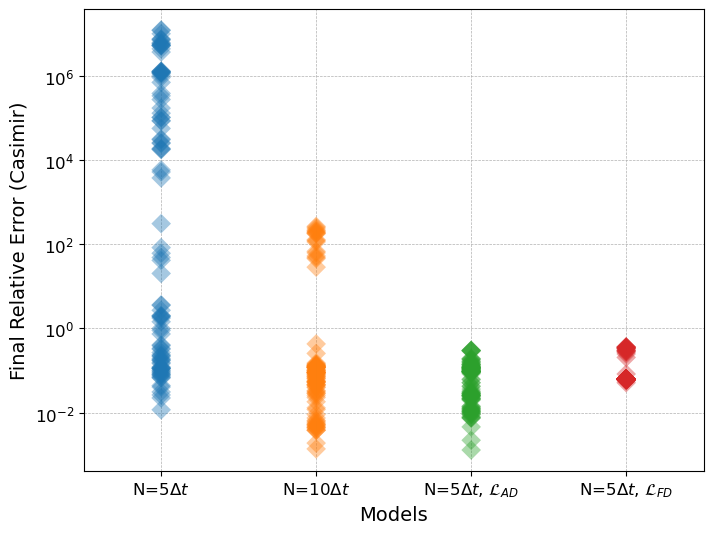

In [120]:
plt.figure(figsize=(8,6))
df = pd.DataFrame({
    "N=5$\Delta t$": baseline_rigidbody_05["holo_over_time_relative_white"].apply(lambda x: x[-1]),
    "N=10$\Delta t$": baseline_rigidbody_1["holo_over_time_relative_white"].apply(lambda x: x[-1]),
    "N=5$\Delta t$, $\mathcal{L}_{AD}$": dict_05_AD_sup_RB[1e-6]["holo_over_time_relative_white"].apply(lambda x: x[-1]),
    "N=5$\Delta t$, $\mathcal{L}_{FD}$": dict_05_FD_unsup_RB[1e-2]["holo_over_time_relative_white"].apply(lambda x: x[-1]),
})
fig, ax = plt.subplots(1,figsize=(8,6))
sns.stripplot(
    df,
    jitter=False,
    alpha=0.4,
    s=10,
    marker="D",
    ax=ax,
)
plt.yscale("log")
plt.ylabel(r"Final Relative Error (Casimir)", fontsize=14)
plt.xlabel("Models", fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.grid(True, which="both", ls="--", linewidth=0.5)
#plt.ylim(1e-4, 1e10)

33


(1.5028581063493263,
 47.505180252310346,
 0.48886885899885135,
 0.6522965607609401)

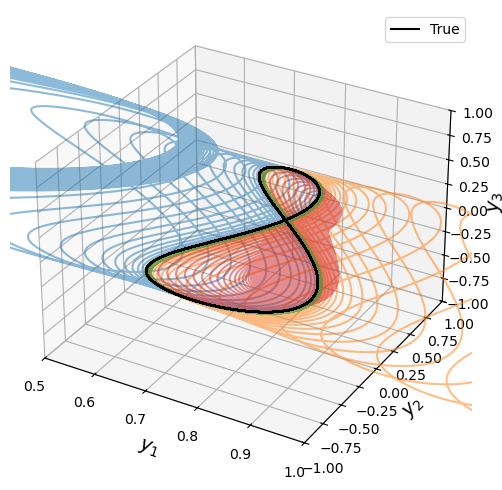

In [156]:
# trajectory
# 3d plot

k= baseline_rigidbody_1["L2"].idxmax()
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
time=-1
ax.set_xlabel("$y_1$", fontsize=14)
ax.set_ylabel("$y_2$", fontsize=14)
ax.set_zlabel("$y_3$", fontsize=14, labelpad=1)
ax.plot(baseline_rigidbody_05["y_pred"][k][:time,0],baseline_rigidbody_05["y_pred"][k][:time,1], baseline_rigidbody_05["y_pred"][k][:time,2], color="C0", alpha=0.5)
ax.plot(baseline_rigidbody_1["y_pred"][k][:time,0],baseline_rigidbody_1["y_pred"][k][:time,1], baseline_rigidbody_1["y_pred"][k][:time,2], color="C1", alpha=0.5)
ax.plot(dict_05_FD_unsup_RB[1e-2]["y_pred"][k][:time,0], dict_05_FD_unsup_RB[1e-2]["y_pred"][k][:time,1],dict_05_FD_unsup_RB[1e-2]["y_pred"][k][:time,2], color="C3", alpha=0.5)
ax.plot(dict_05_AD_sup_RB[1e-6]["y_pred"][k][:time,0], dict_05_AD_sup_RB[1e-6]["y_pred"][k][:time,1],dict_05_AD_sup_RB[1e-6]["y_pred"][k][:time,2], color="C2", alpha=0.6)


#ax.plot(dict_05_FD_unsup_RB[1e-3]["y_pred"][k][:time,0], dict_05_FD_unsup_RB[1e-3]["y_pred"][k][:time,1],dict_05_FD_unsup_RB[1e-3]["y_pred"][k][:time,2], label="N=5, $\mathcal{L}_{FD}$", color="C3", alpha=0.5)

#ax.plot(dict_05_AD_sup_RB[1e-4]["y_pred"][k][:time,0], dict_05_AD_sup_RB[1e-4]["y_pred"][k][:time,1],dict_05_AD_sup_RB[1e-4]["y_pred"][k][:time,2], label="AD sup l=1e-4", linestyle="dashed")
ax.plot(baseline_rigidbody_1["y_true"][k][:time,0],baseline_rigidbody_1["y_true"][k][:time,1], baseline_rigidbody_1["y_true"][k][:time,2], label="True", color="black")
plt.legend()
ax.set_xlim([0.5,1])
ax.set_ylim([-1,1])
ax.set_zlim([-1,1])
print(k)
baseline_rigidbody_05["L2_over_time_relative"][k].mean(), baseline_rigidbody_1["L2_over_time_relative"][k].mean(),dict_05_FD_unsup_RB[1e-2]["L2_over_time_relative"][k].mean(), dict_05_AD_sup_RB[1e-6]["L2_over_time_relative"][k].mean(), 


33


(1.5028581063493263,
 47.505180252310346,
 0.48886885899885135,
 0.6522965607609401)

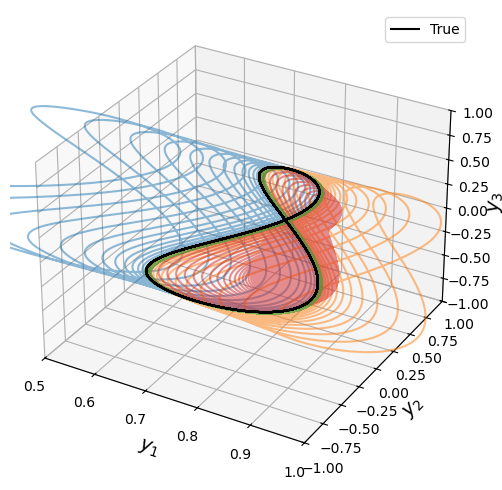

In [325]:
# trajectory
# 3d plot

k= baseline_rigidbody_1["L2"].idxmax()
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
time=2000
ax.set_xlabel("$y_1$", fontsize=14)
ax.set_ylabel("$y_2$", fontsize=14)
ax.set_zlabel("$y_3$", fontsize=14, labelpad=1)
ax.plot(baseline_rigidbody_05["y_pred"][k][:time,0],baseline_rigidbody_05["y_pred"][k][:time,1], baseline_rigidbody_05["y_pred"][k][:time,2], color="C0", alpha=0.5)
ax.plot(baseline_rigidbody_1["y_pred"][k][:time,0],baseline_rigidbody_1["y_pred"][k][:time,1], baseline_rigidbody_1["y_pred"][k][:time,2], color="C1", alpha=0.5)
ax.plot(dict_05_FD_unsup_RB[1e-2]["y_pred"][k][:,0], dict_05_FD_unsup_RB[1e-2]["y_pred"][k][:,1],dict_05_FD_unsup_RB[1e-2]["y_pred"][k][:,2], color="C3", alpha=0.5)
ax.plot(dict_05_AD_sup_RB[1e-6]["y_pred"][k][:,0], dict_05_AD_sup_RB[1e-6]["y_pred"][k][:,1],dict_05_AD_sup_RB[1e-6]["y_pred"][k][:,2], color="C2", alpha=0.6)


#ax.plot(dict_05_FD_unsup_RB[1e-3]["y_pred"][k][:time,0], dict_05_FD_unsup_RB[1e-3]["y_pred"][k][:time,1],dict_05_FD_unsup_RB[1e-3]["y_pred"][k][:time,2], label="N=5, $\mathcal{L}_{FD}$", color="C3", alpha=0.5)

#ax.plot(dict_05_AD_sup_RB[1e-4]["y_pred"][k][:time,0], dict_05_AD_sup_RB[1e-4]["y_pred"][k][:time,1],dict_05_AD_sup_RB[1e-4]["y_pred"][k][:time,2], label="AD sup l=1e-4", linestyle="dashed")
ax.plot(baseline_rigidbody_1["y_true"][k][:time,0],baseline_rigidbody_1["y_true"][k][:time,1], baseline_rigidbody_1["y_true"][k][:time,2], label="True", color="black")
plt.legend()
ax.set_xlim([0.5,1])
ax.set_ylim([-1,1])
ax.set_zlim([-1,1])
print(k)
baseline_rigidbody_05["L2_over_time_relative"][k].mean(), baseline_rigidbody_1["L2_over_time_relative"][k].mean(),dict_05_FD_unsup_RB[1e-2]["L2_over_time_relative"][k].mean(), dict_05_AD_sup_RB[1e-6]["L2_over_time_relative"][k].mean(), 


## KS

In [39]:
def compute_metrics_ks(data, data_true=None):
    if data_true is not None:
        data["y_true"] = data_true.values
    data["y_true"] = data["y_true"].apply(lambda x: np.array(x))
    true_shape = data["y_true"][0].shape
    data["y_pred"] = data["y_pred"].apply(lambda x: np.array(x)[:true_shape[0], :true_shape[1]])
    data["L2"] = data.apply(lambda x: np.mean(np.array((x["y_true"] - x["y_pred"])**2)), axis=1)
    data["L2_over_time"] = data.apply(lambda x: np.array((x["y_true"] - x["y_pred"])**2).mean(axis=1), axis=1)
    data["L2_over_time_relative"] = data.apply(lambda x: x["L2_over_time"]/np.array(x["y_true"]**2).mean(axis=1), axis=1)
    data["L2_over_time_relative_white"] = data.apply(lambda x: np.sqrt(((x["y_true"]-x["y_pred"])**2).mean(axis=1)/((x["y_true"])**2).mean(axis=1)), axis=1)
    # conservation
    data["sum_true"] = data.apply(lambda x: np.sum(x["y_true"], axis=1), axis=1)
    data["sum_pred"] = data.apply(lambda x: np.sum(x["y_pred"], axis=1), axis=1)
    data["sum_error"] = data.apply(lambda x: np.abs(x["sum_true"] - x["sum_pred"]), axis=1) # true very close to 0 initially
    data["sum_error_mean"] = data.apply(lambda x: np.mean(x["sum_error"]), axis=1)
    data["sum_over_time"] = data.apply(lambda x: np.sqrt(((x["sum_true"]-x["sum_pred"])**2)), axis=1)
    return data

In [40]:
baseline_ks_04_1000 = pd.read_json('data_exp/KS_gridsearch/none_aug_0.4_16_s5wmgd8o/model_1.396e-04_longrun_dt_128.0_0.2.json').T
baseline_ks_04_1000 = compute_metrics_ks(baseline_ks_04_1000)

In [41]:
baseline_ks_08_1000 = pd.read_json('data_exp/KS_gridsearch/none_aug_0.8_17_sqfbcwi6/model_4.720e-04_longrun_dt_128.0_0.2.json').T
baseline_ks_08_1000 = compute_metrics_ks(baseline_ks_08_1000)

In [42]:
baseline_ks_2_1000 = pd.read_json('data_exp/KS_gridsearch/none_aug_2_18_n6ify3l8/model_2.258e-03_longrun_dt_128.0_0.2.json').T
baseline_ks_2_1000 = compute_metrics_ks(baseline_ks_2_1000)

In [43]:
dt_path = 'data_exp/KS/ks0.4_val.npy'
states = np.load(dt_path, allow_pickle=True).item()["states"]

results = {}
for k in range(states.shape[0]):
    results[k] = {
                    'y_true': np.array(states[k]).tolist(),
                }
baseline_ks_val = pd.DataFrame(results).T


### Validation

In [45]:
### FD unsup, optimal lambda on val data
data_path = 'data_exp/KS'
dict_04_FD_unsup_KS_val = {}
for folder in os.listdir(data_path):
    if "0.4" in folder:
        if "FD_unsup" in folder:
            cfg = OmegaConf.load(os.path.join(data_path, folder, "config.yaml"))
            lambda_ = cfg.train.lambda0
            for file in os.listdir(os.path.join(data_path,folder)):
                if ".npy" in file:
                    data = np.load(os.path.join(data_path, folder, file), allow_pickle=True)
                    data = define_df_from_npy(data)
                    data["y_true"] = baseline_ks_val["y_true"]
                    data = compute_metrics_ks(data)
                    dict_04_FD_unsup_KS_val[lambda_] = data
                

In [46]:
### AD sup, optimal lambda on val data
data_path = 'data_exp/KS'
dict_04_AD_sup_KS_val = {}
for folder in os.listdir(data_path):
    if "0.4" in folder:
        if "AD_sup" in folder:
            cfg = OmegaConf.load(os.path.join(data_path, folder, "config.yaml"))
            lambda_ = cfg.train.lambda0
            for file in os.listdir(os.path.join(data_path,folder)):
                if ".npy" in file:
                    data = np.load(os.path.join(data_path, folder, file), allow_pickle=True)
                    data = define_df_from_npy(data)
                    data["y_true"] = baseline_ks_val["y_true"]
                    data = compute_metrics_ks(data)
                    dict_04_AD_sup_KS_val[lambda_] = data
            

In [336]:
means_AD_ks = []
means_FD_ks = []
for lambda_ in [5e-12, 1e-12, 5e-13, 1e-13]:
    means_AD_ks.append(dict_04_AD_sup_KS_val[lambda_]["L2"].mean())

for lambda_ in [1e-4, 1e-5, 1e-6, 1e-7, 1e-8]:
    means_FD_ks.append(dict_04_FD_unsup_KS_val[lambda_]["L2"].mean())


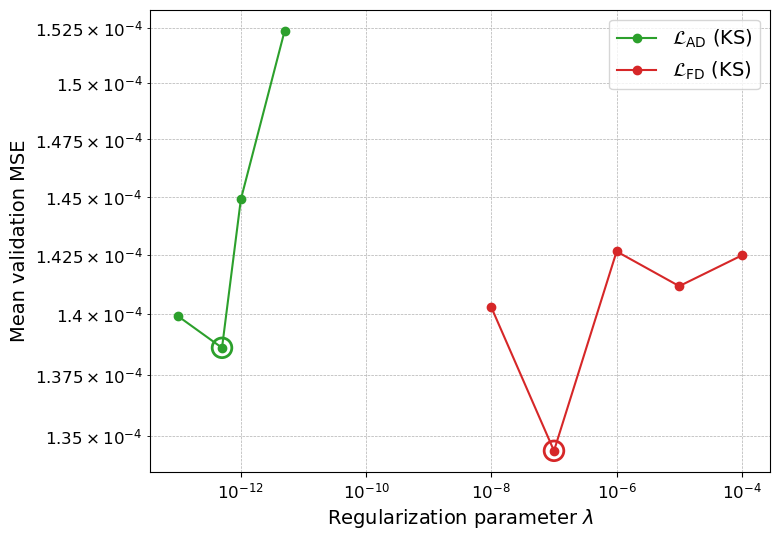

In [338]:
plt.figure(figsize=(8,6))
plt.plot([5e-12, 1e-12, 5e-13, 1e-13], means_AD_ks, label=r"$\mathcal{L}_{\text{AD}}$ (KS)", marker='o',color="C2")
plt.plot([1e-4, 1e-5, 1e-6, 1e-7, 1e-8], means_FD_ks, label=r"$\mathcal{L}_{\text{FD}}$ (KS)", marker='o', color="C3")
plt.scatter(5e-13, means_AD_ks[2], s=200, facecolors='none', edgecolors='C2', linewidths=2)
plt.scatter(1e-7, means_FD_ks[-2], s=200, facecolors='none', edgecolors='C3', linewidths=2)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.xscale("log")
plt.yscale("log")
plt.legend(fontsize=14)
plt.xlabel("Regularization parameter $\lambda$", fontsize=14)
plt.ylabel("Mean validation MSE", fontsize=14)
plt.grid(True, which="both", ls="--", linewidth=0.5)

### Results on test data 

In [48]:
### AD sup, on test data
data_path = 'data_exp/KS'
dict_04_AD_sup_KS = {}
for folder in os.listdir(data_path):
    if "0.4" in folder:
        if "AD_sup" in folder:
            cfg = OmegaConf.load(os.path.join(data_path, folder, "config.yaml"))
            lambda_ = cfg.train.lambda0
            for file in os.listdir(os.path.join(data_path,folder)):
                if ".json" in file:
                    data = pd.read_json(os.path.join(data_path, folder, file)).T
                    data["y_true"] = baseline_ks_04_1000["y_true"]
                    data = compute_metrics_ks(data)
                    dict_04_AD_sup_KS[lambda_] = data
                

In [49]:
### FD unsup, on test data
data_path = 'data_exp/KS'
dict_04_FD_unsup_KS = {}
for folder in os.listdir(data_path):
    if "0.4" in folder:
        if "FD_unsup" in folder:
            cfg = OmegaConf.load(os.path.join(data_path, folder, "config.yaml"))
            lambda_ = cfg.train.lambda0
            for file in os.listdir(os.path.join(data_path,folder)):
                if ".json" in file:
                    if "val" not in file:
                        data = pd.read_json(os.path.join(data_path, folder, file)).T
                        data["y_true"] = baseline_ks_04_1000["y_true"]
                        data = compute_metrics_ks(data)
                        dict_04_FD_unsup_KS[lambda_] = data
                

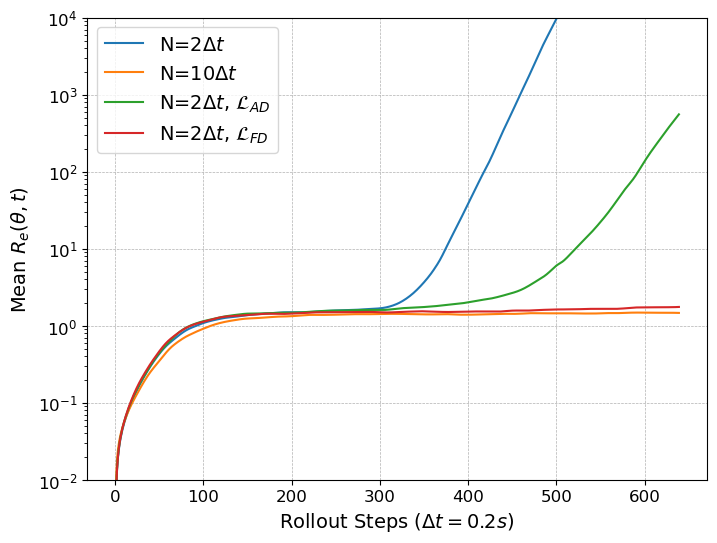

In [10]:
# Relative error over time
plt.figure(figsize=(8,6))
plt.plot(baseline_ks_04_1000["L2_over_time_relative_white"].mean(), label="N=2$\Delta t$")
plt.plot(baseline_ks_2_1000["L2_over_time_relative_white"].mean(), label="N=10$\Delta t$")
plt.plot(dict_04_AD_sup_KS[5e-13]["L2_over_time_relative_white"].mean(), label="N=2$\Delta t$, $\mathcal{L}_{AD}$")
plt.plot(dict_04_FD_unsup_KS[1e-7]["L2_over_time_relative_white"].mean(), label="N=2$\Delta t$, $\mathcal{L}_{FD}$", color="C3")
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.yscale("log")
plt.legend(fontsize=14)
plt.xlabel("Rollout Steps ($\Delta t = 0.2s$)", fontsize=14)
plt.ylabel(r"Mean $R_e(\theta, t)$", fontsize=14)
plt.ylim(1e-2, 1e4)
plt.grid(True, which="major", ls="--", linewidth=0.5)

(0.1, 10000000000.0)

<Figure size 800x600 with 0 Axes>

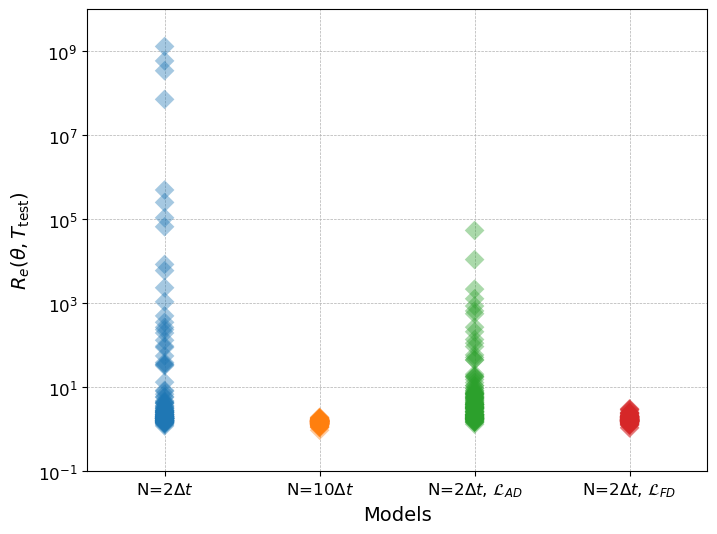

In [11]:
plt.figure(figsize=(8,6))
df = pd.DataFrame({
    "N=2$\Delta t$": baseline_ks_04_1000["L2_over_time_relative_white"].apply(lambda x: x[-1]),
    "N=10$\Delta t$": baseline_ks_2_1000["L2_over_time_relative_white"].apply(lambda x: x[-1]),
    "N=2$\Delta t$, $\mathcal{L}_{AD}$": dict_04_AD_sup_KS[5e-13]["L2_over_time_relative_white"].apply(lambda x: x[-1]),
    "N=2$\Delta t$, $\mathcal{L}_{FD}$": dict_04_FD_unsup_KS[1e-7]["L2_over_time_relative_white"].apply(lambda x: x[-1]),
})
fig, ax = plt.subplots(1,figsize=(8,6))
sns.stripplot(
    df,
    jitter=False,
    alpha=0.4,
    s=10,
    marker="D",
    ax=ax,
)
plt.yscale("log")
plt.ylabel(r"$R_e(\theta, T_{\text{test}})$", fontsize=14)
plt.xlabel("Models", fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.ylim(1e-1,1e10 )
#plt.ylim(1e-4, 1e10)

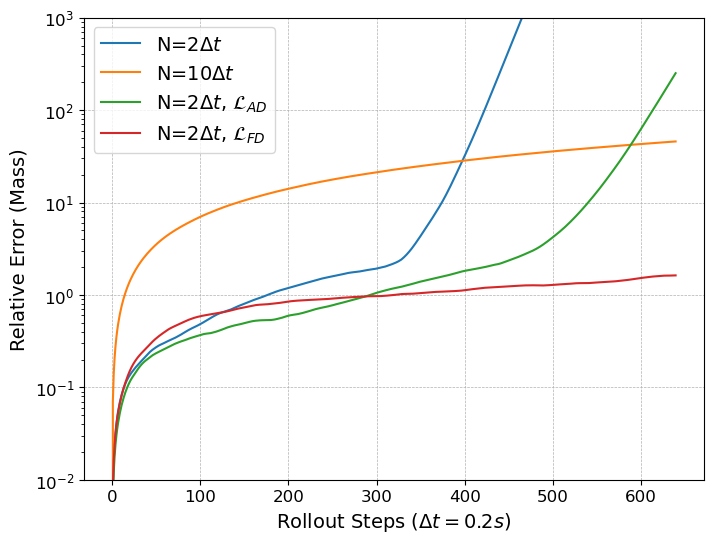

In [12]:
# Relative conservation error over time
plt.figure(figsize=(8,6))
plt.plot(baseline_ks_04_1000["sum_over_time"].mean(), label="N=2$\Delta t$")
plt.plot(baseline_ks_2_1000["sum_over_time"].mean(), label="N=10$\Delta t$")
plt.plot(dict_04_AD_sup_KS[5e-13]["sum_over_time"].mean(), label="N=2$\Delta t$, $\mathcal{L}_{AD}$")
plt.plot(dict_04_FD_unsup_KS[1e-7]["sum_over_time"].mean(), label="N=2$\Delta t$, $\mathcal{L}_{FD}$", color="C3")
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.yscale("log")
plt.legend(loc="upper left", fontsize=14)
plt.xlabel("Rollout Steps ($\Delta t = 0.2s$)", fontsize=14)
plt.ylabel(r"Relative Error (Mass)", fontsize=14)
plt.ylim(1e-2, 1e3)
plt.grid(True, which="major", ls="--", linewidth=0.5)

<Figure size 800x600 with 0 Axes>

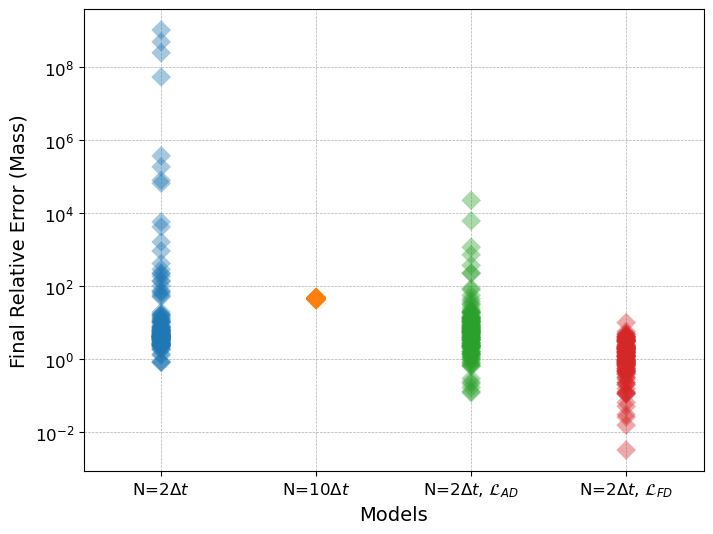

In [321]:
plt.figure(figsize=(8,6))
df = pd.DataFrame({
    "N=2$\Delta t$": baseline_ks_04_1000["sum_over_time"].apply(lambda x: x[-1]),
    "N=10$\Delta t$": baseline_ks_2_1000["sum_over_time"].apply(lambda x: x[-1]),
    "N=2$\Delta t$, $\mathcal{L}_{AD}$": dict_04_AD_sup_KS[5e-13]["sum_over_time"].apply(lambda x: x[-1]),
    "N=2$\Delta t$, $\mathcal{L}_{FD}$": dict_04_FD_unsup_KS[1e-7]["sum_over_time"].apply(lambda x: x[-1]),
})
fig, ax = plt.subplots(1,figsize=(8,6))
sns.stripplot(
    df,
    jitter=False,
    alpha=0.4,
    s=10,
    marker="D",
    ax=ax,
)
plt.yscale("log")
plt.ylabel(r"Final Relative Error (Mass)", fontsize=14)
plt.xlabel("Models", fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.grid(True, which="both", ls="--", linewidth=0.5)
#plt.ylim(1e-4, 1e10)

In [265]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_ks(data, idx, L=64, T=200):
    fig, ax = plt.subplots(1, 2, figsize=(7, 5), sharey=True)

    # Choose limits (example: symmetric)
    vmin = min(data["y_true"][idx].min(), data["y_pred"][idx].min())
    vmax = max(data["y_true"][idx].max(), data["y_pred"][idx].max())

    im = ax[0].imshow(
        data["y_true"][idx],
        extent=[0, L, 340, 640],
        cmap="PuOr_r",
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
        origin="lower",
    )
    ax[0].set_title("True", fontsize=14)
    ax[0].set_xlabel("x [m]")
    ax[0].set_ylabel("Rollout Steps ($\Delta t = 0.2s$)")

    ax[1].imshow(
        data["y_pred"][idx],
        extent=[0, L, 340, 640],
        cmap="PuOr_r",
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
        origin="lower",
    )
    ax[1].set_title("Predicted", fontsize=14)
    ax[1].set_xlabel("x [m]")

    divider = make_axes_locatable(ax[1])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im, cax=cax)

    #plt.tight_layout()
    plt.tick_params(axis='both', which='major', labelsize=12)
    plt.tick_params(axis='both', which='minor', labelsize=12)
    fig.suptitle(f"KS trajectory {idx}, MSE={data['L2'][idx]:.2e}", fontsize=16, y=1.02)
    plt.show()


In [13]:
def plot_multi_ks_5_row(data1, data2, data3, data4, idx, L=64, T=200):

    fig, ax = plt.subplots(1, 5, figsize=(8, 6), sharey=True)

    fields = [
        data1["y_true"][idx],
        data1["y_pred"][idx],
        data2["y_pred"][idx],
        data3["y_pred"][idx],
        data4["y_pred"][idx],
    ]

    titles = ["True", "N=2$\Delta t$", "N=10$\Delta t$", 
              r"N=2$\Delta t$, $\mathcal{L}_{\text{AD}}$", 
              r"N=2$\Delta t$, $\mathcal{L}_{\text{FD}}$"]

    colors = ["black", "C0", "C1", "C2", "C3"]

    vmin = min(f.min() for f in data1["y_true"])
    vmax = max(f.max() for f in data1["y_true"])

    extent = [0, L, 0, 640]

    for i in range(5):
        im = ax[i].imshow(
            fields[i],
            extent=extent,
            cmap="PuOr_r",
            aspect="auto",
            vmin=vmin,
            vmax=vmax,
            origin="lower"
        )

        ax[i].set_title(titles[i], fontsize=14, color=colors[i])
        ax[i].set_xlabel("x [m]", fontsize=14)
        ax[i].tick_params(axis='both', which='major', labelsize=12)
        ax[i].tick_params(axis='both', which='minor', labelsize=12)

    ax[0].set_ylabel("Rollout steps ($\Delta t$ = 0.2s)", fontsize=14)

    plt.subplots_adjust(wspace=0.2, right=0.9)

    # FULL HEIGHT COLORBAR
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    fig.colorbar(im, cax=cbar_ax)

    plt.show()

    print(
        data1["L2"][idx].mean(),
        data2["L2"][idx].mean(),
        data3["L2"][idx].mean(),
        data4["L2"][idx].mean(),
    )


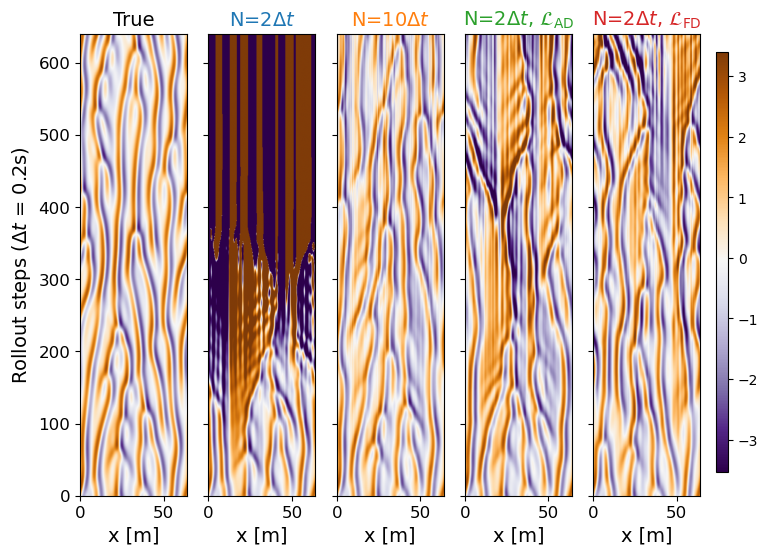

4.7493610280758024e+16 3.2433134728261663 4.159646243548438 3.9074170034550377


In [14]:
plot_multi_ks_5_row(baseline_ks_04_1000,baseline_ks_2_1000, dict_04_AD_sup_KS[5e-13], dict_04_FD_unsup_KS[1e-7], baseline_ks_04_1000["L2"].idxmax())

# Figure 2: Jacobian norms

In [50]:
def compute_jacobian(model_fn):
    jac_single = jax.jacfwd(model_fn)
    return jax.jit(jax.vmap(jac_single))

def J_error(model, trueF, y):
    jacob = compute_jacobian(model.model_aug)(y)
    jacob_true = compute_jacobian(trueF)(y)
    #RJE = jnp.linalg.norm(jacob - jacob_true)/ jnp.linalg.norm(jacob_true)
    #MSE style
    JE = jnp.mean((jacob-jacob_true)**2)
    return JE 


def offline_error(model, trueF, y):
    F_pred = jax.vmap(lambda x: model.model_aug(x))(y)
    F_true = jax.vmap(lambda x: trueF(x))(y)
    offlineE = np.mean((F_pred-F_true)**2)
    return offlineE


In [51]:
def make_jacobian_sqnorm_fn(model, num_samples=4):

    def jacobian_sqnorm(y0, key):
        keys = jax.random.split(key, num_samples)

        def single_estimate(k):
            v = jax.random.normal(k, y0.shape)  
            _, jvp = jax.jvp(model, (y0,), (v,))
            return jnp.sum(jvp**2)

        estimates = jax.vmap(single_estimate)(keys)

        # Frobenius squared estimate
        return jnp.mean(estimates)

    return jax.jit(jax.vmap(jacobian_sqnorm))

def J_error_hutch(model, trueF, y, keys):

    # Difference operator
    diff_fn = lambda x: model.model_aug(x) - trueF(x)

    jac_diff_sq = make_jacobian_sqnorm_fn(diff_fn)(y, keys)

    # Mean over batch (MSE style)
    return jnp.mean(jac_diff_sq)


In [52]:
def jointplot_Jf(df, xname, yname, color):
    sns.jointplot(df, x=xname, y =yname, color=color, kind="hist")
    x = np.linspace(df[yname].min(),df[yname].max())
    plt.plot(x,x, color="black")
    plt.yscale("log")
    plt.xscale("log")
    #plt.ylim(0, max(df[df.columns[0]].max(), df[df.columns[1]].max(),df[df.columns[2]].max(), df[df.columns[3]].max(),df[df.columns[4]].max())) 
    #plt.xlim(0, max(df[df.columns[0]].max(), df[df.columns[1]].max(),df[df.columns[2]].max(), df[df.columns[3]].max(),df[df.columns[4]].max()) )
    plt.show()

## Twobody

In [56]:
model_baseline_tb_002 = load_best_model_dt(0.01, "data_exp/twobody_dt001_8s/none_aug_0.02_2_fc1i7jba", "twobody", "RK4", "RK4", dt_num=0.01, duration=100)
model_baseline_tb_005 = load_best_model_dt(0.01, "data_exp/twobody_dt001_8s/none_aug_0.05_5_zvjsiwkz",  "twobody", "RK4", "RK4", dt_num=0.01, duration=100 )

In [57]:
data_path = 'data_exp/twobody_dt001_8s'
model_dict_002_AD_sup_8s = {}
for folder in os.listdir(data_path):
    if "0.02" in folder:
        if "AD_sup" in folder:
            cfg = OmegaConf.load(os.path.join(data_path, folder, "config.yaml"))
            lambda_ = cfg.train.lambda0
            if lambda_ not in [0.0, 1e-7, 5e-8]:
                model_dict_002_AD_sup_8s[lambda_] = load_best_model_dt(
                    0.01,
                    os.path.join(data_path, folder),
                    "twobody",
                    "RK4",
                    data_integration_method="RK4",
                    dt_num=0.01,
                    duration=100)
            

In [58]:
data_path = 'data_exp/twobody_dt001_8s'
model_dict_002_FD_unsup_8s = {}
for folder in os.listdir(data_path):
    if "0.02" in folder:
        if "FD_unsup" in folder:
            cfg = OmegaConf.load(os.path.join(data_path, folder, "config.yaml"))
            lambda_ = cfg.train.lambda0
            if lambda_ not in [0.0, 1e-7, 5e-8]:
                model_dict_002_FD_unsup_8s[lambda_] = load_best_model_dt(
                    0.01,
                    os.path.join(data_path, folder),
                    "twobody",
                    "RK4",
                    data_integration_method="RK4",
                    dt_num=0.01,
                    duration=100)
            

In [125]:
y_true_TB_001 = get_states(baseline_tb_002_8s, bool_true=True)

(1000100, 4) (4,)


In [59]:
dt_path = 'data_exp/twobody_dt001_8s/2body_full_train.npy'

states = np.load(dt_path, allow_pickle=True).item()["states"]

results = {}
for k in range(states.shape[0]):
    results[k] = {
                    'y_true': np.array(states[k]).tolist(),
                }
y_true_TB_train = pd.DataFrame(results).T
y_true_TB_train["y_true"] = y_true_TB_train["y_true"].apply(lambda x: np.array(x))

In [164]:
y_true_TB_train = get_states(y_true_TB_train, bool_true=True)

(32040, 4) (4,)


In [126]:
jac_tb_002_true = compute_jacobian_test(model_baseline_tb_002, y_true_TB_001, bool_true=False)
jac_tb_005_true = compute_jacobian_test(model_baseline_tb_005, y_true_TB_001, bool_true=False)
jac_tb_002_AD_true = compute_jacobian_test(model_dict_002_AD_sup_8s[5e-13], y_true_TB_001, bool_true=False)
jac_tb_002_FD_true = compute_jacobian_test(model_dict_002_FD_unsup_8s[5e-13], y_true_TB_001, bool_true=False)

In [127]:
jac_true_TB = compute_jacobian_test(F_twobody, y_true_TB_001, bool_true=True)

In [22]:
# Lipschitz constant
jac_true_TB.max(), jac_tb_002_true.max(), jac_tb_005_true.max(), jac_tb_002_AD_true.max(), jac_tb_002_FD_true.max()

(Array(78.84399777, dtype=float64),
 Array(24.93255207, dtype=float64),
 Array(25.53487765, dtype=float64),
 Array(25.29807928, dtype=float64),
 Array(24.90405863, dtype=float64))

In [350]:
# L traj
baseline_tb_002_8s["L2"].mean(), baseline_tb_005_8s["L2"].mean(), dict_002_AD_sup_8s[5e-13]["L2"].mean(),  dict_002_FD_unsup_8s[5e-13]["L2"].mean()

(4952059742939160.0,
 0.017384549933637708,
 0.010050687397640666,
 263.69833253687216)

In [354]:
# offline error F
print(offline_error(model_baseline_tb_002, F_twobody, y_true_TB_001))
print(offline_error(model_baseline_tb_005, F_twobody, y_true_TB_001))
print(offline_error(model_dict_002_AD_sup_8s[5e-13], F_twobody, y_true_TB_001))
print(offline_error(model_dict_002_FD_unsup_8s[5e-13], F_twobody, y_true_TB_001))

1.4169226937104578e-06
4.821700281852882e-06
1.1399238171440138e-06
1.1110772708675002e-06


In [165]:
# offline error F train
print(offline_error(model_baseline_tb_002, F_twobody, y_true_TB_train))
print(offline_error(model_baseline_tb_005, F_twobody, y_true_TB_train))
print(offline_error(model_dict_002_AD_sup_8s[5e-13], F_twobody, y_true_TB_train))
print(offline_error(model_dict_002_FD_unsup_8s[5e-13], F_twobody, y_true_TB_train))

1.4379933321222546e-06
4.991457495049246e-06
1.1567774444315148e-06
1.0583754734795708e-06


In [23]:
# J error 
print(J_error(model_baseline_tb_002, F_twobody, y_true_TB_001))
print(J_error(model_baseline_tb_005, F_twobody, y_true_TB_001))
print(J_error(model_dict_002_AD_sup_8s[5e-13], F_twobody, y_true_TB_001))
print(J_error(model_dict_002_FD_unsup_8s[5e-13], F_twobody, y_true_TB_001))

5.736169246918082
5.5877189747048925
5.712608660716373
5.721793289423995


In [166]:
# J error train
print(J_error(model_baseline_tb_002, F_twobody, y_true_TB_train))
print(J_error(model_baseline_tb_005, F_twobody, y_true_TB_train))
print(J_error(model_dict_002_AD_sup_8s[5e-13], F_twobody, y_true_TB_train))
print(J_error(model_dict_002_FD_unsup_8s[5e-13], F_twobody, y_true_TB_train))

7.051650538879177
6.866935551106653
6.97158971600323
6.995823558310399


In [30]:
B = y_true_TB_001.shape[0]
master_key = jax.random.PRNGKey(42)
keys_TB = jax.random.split(master_key, B)

#keys_TB = jax.random.split(jax.random.PRNGKey(0), y_true_TB_001.shape[0])

In [36]:
dim_TB = 4 

In [38]:
# J error hutch
print(J_error_hutch(model_baseline_tb_002, F_twobody, y_true_TB_001, keys_TB) /dim_TB**2) 
print(J_error_hutch(model_baseline_tb_005, F_twobody, y_true_TB_001, keys_TB)/ dim_TB**2)
print(J_error_hutch(model_dict_002_AD_sup_8s[5e-13], F_twobody, y_true_TB_001, keys_TB) /dim_TB**2)
print(J_error_hutch(model_dict_002_FD_unsup_8s[5e-13], F_twobody, y_true_TB_001, keys_TB) /dim_TB**2)

5.758354344284454
5.608873750474536
5.73601092011098
5.744491511504475


We keep the conclusions, only a bit overestimated compared to true Jacobian estimation

In [128]:
data_jac_tb = pd.DataFrame({
    "N=2$\Delta t$": jac_tb_002_true,
    "N=5$\Delta t$": jac_tb_005_true,
    "N=2$\Delta t$, $\mathcal{L}_{\text{AD}}$": jac_tb_002_AD_true,
    "N=2$\Delta t$, $\mathcal{L}_{\text{FD}}$": jac_tb_002_FD_true,
    "$||J_F(x)||$": jac_true_TB 
})

In [136]:
print(np.mean((jac_tb_002_true-jac_true_TB )**2))
print(np.mean((jac_tb_005_true-jac_true_TB )**2))
print(np.mean((jac_tb_002_AD_true-jac_true_TB )**2))
print(np.mean((jac_tb_002_FD_true-jac_true_TB )**2))

36.84675298598721
35.756203928311
34.582935555571076
34.7697455878966


## Rigidbody

In [60]:
model_baseline_rb_05 = load_best_model_dt(0.1, "/data_exp/rigidbody/none_aug_0.5_5_y3af0b13", "rigidbody", "RK4", "RK4", dt_num=0.01, duration=800)
model_baseline_rb_1 = load_best_model_dt(0.1, "/data_exp/rigidbody/none_aug_1.0_4_6dmux55q", "rigidbody", "RK4", "RK4", dt_num=0.01, duration=800)

In [61]:
data_path = 'data_exp/rigidbody'
model_dict_05_RB_AD_sup = {}
for folder in os.listdir(data_path):
    if "0.5" in folder:
        if "AD_sup" in folder:
            cfg = OmegaConf.load(os.path.join(data_path, folder, "config.yaml"))
            lambda_ = cfg.train.lambda0
            model_dict_05_RB_AD_sup[lambda_] = load_best_model_dt(
                0.1,
                os.path.join(data_path, folder),
                "rigidbody",
                "RK4",
                data_integration_method="RK4",
                dt_num=0.01,
                duration=800)
            

In [63]:
data_path = 'data_exp/rigidbody'
model_dict_05_RB_FD_unsup = {}
for folder in os.listdir(data_path):
    if "0.5" in folder:
        if "FD_unsup" in folder:
            cfg = OmegaConf.load(os.path.join(data_path, folder, "config.yaml"))
            lambda_ = cfg.train.lambda0
            model_dict_05_RB_FD_unsup[lambda_] = load_best_model_dt(
                0.1,
                os.path.join(data_path, folder),
                "rigidbody",
                "RK4",
                data_integration_method="RK4",
                dt_num=0.01,
                duration=800)
            

In [141]:
y_true_RB = get_states(baseline_rigidbody_05, bool_true=True)

(800100, 3) (3,)


In [142]:
jac_rb_baseline_05 = compute_jacobian_test(model_baseline_rb_05, y_true_RB, bool_true=False)
jac_rb_baseline_1 = compute_jacobian_test(model_baseline_rb_1, y_true_RB, bool_true=False)
jac_rb_AD_sup_05 = compute_jacobian_test(model_dict_05_RB_AD_sup[1e-6], y_true_RB, bool_true=False)
jac_rb_FD_unsup_05 = compute_jacobian_test(model_dict_05_RB_FD_unsup[1e-2], y_true_RB, bool_true=False)

In [143]:
jac_true_RB = compute_jacobian_test(F_rigidbody, y_true_RB, bool_true=True)

In [71]:
# Lipschitz constant 
jac_true_RB.max(), jac_rb_baseline_05.max(), jac_rb_baseline_1.max(), jac_rb_AD_sup_05.max(), jac_rb_FD_unsup_05.max()

(Array(1.00728695, dtype=float64),
 Array(1.04337674, dtype=float64),
 Array(1.03498425, dtype=float64),
 Array(1.04680041, dtype=float64),
 Array(1.00188601, dtype=float64))

In [393]:
# L traj
baseline_rigidbody_05["L2"].mean(), baseline_rigidbody_1["L2"].mean(), dict_05_AD_sup_RB[1e-6]["L2"].mean(), dict_05_FD_unsup_RB[1e-2]["L2"].mean()

(14053.753349487743,
 1.62094207602484,
 0.17891204534698726,
 0.15217806039211654)

In [399]:
# offline error F
print(offline_error(model_baseline_rb_05, F_rigidbody, y_true_RB))
print(offline_error(model_baseline_rb_1, F_rigidbody, y_true_RB))
print(offline_error(model_dict_05_RB_AD_sup[1e-6], F_rigidbody, y_true_RB))
print(offline_error(model_dict_05_RB_FD_unsup[1e-2], F_rigidbody, y_true_RB))

4.224851021662706e-07
5.014233223321791e-07
4.0877284784366623e-07
5.164713792140041e-06


In [72]:
# J error
print(J_error(model_baseline_rb_05, F_rigidbody, y_true_RB))
print(J_error(model_baseline_rb_1, F_rigidbody, y_true_RB))
print(J_error(model_dict_05_RB_AD_sup[1e-6], F_rigidbody, y_true_RB))
print(J_error(model_dict_05_RB_FD_unsup[1e-2], F_rigidbody, y_true_RB))

0.007839894332821552
0.007285849485749228
0.0004507706569300414
0.005883174178140932


In [46]:
B = y_true_RB.shape[0]
master_key = jax.random.PRNGKey(42)
keys_RB = jax.random.split(master_key, B)

dim_RB = 3

In [47]:
# J error Hutch
print(J_error_hutch(model_baseline_rb_05, F_rigidbody, y_true_RB, keys_RB) / dim_RB**2)
print(J_error_hutch(model_baseline_rb_1, F_rigidbody, y_true_RB, keys_RB) / dim_RB**2)
print(J_error_hutch(model_dict_05_RB_AD_sup[1e-6], F_rigidbody, y_true_RB, keys_RB) / dim_RB**2)
print(J_error_hutch(model_dict_05_RB_FD_unsup[1e-2], F_rigidbody, y_true_RB, keys_RB) / dim_RB**2)

0.007839741159474632
0.007284775538274775
0.0004505781442703824
0.0058846929388943914


In [148]:
data_jac_rb = pd.DataFrame({
    "N=2$\Delta t$": jac_rb_baseline_05,
    "N=5$\Delta t$": jac_rb_baseline_1,
    "N=2$\Delta t$, $\mathcal{L}_{\text{AD}}$": jac_rb_AD_sup_05,
    "N=2$\Delta t$, $\mathcal{L}_{\text{FD}}$": jac_rb_FD_unsup_05,
    "$||J_F(x)||$": jac_true_RB 
})

## KS

In [ ]:
# Hutchinson otherwise too heavy 
def make_jacobian_norm_fn_ks(model, num_samples=4):
    def jacobian_norm(y0, key):
        keys = jax.random.split(key, num_samples)

        def single_estimate(k):
            v = jax.random.normal(k, y0.shape)
            _, jvp = jax.jvp(model, (y0,), (v,))
            return jnp.sum(jvp**2)

        estimates = jax.vmap(single_estimate)(keys)
        return jnp.sqrt(jnp.mean(estimates))

    return jax.jit(jax.vmap(jacobian_norm))


def compute_jacobian_test_ks(model, y, keys, bool_true=False):
    if bool_true:
        jacobian_norms_fn = make_jacobian_norm_fn_ks(model)(y, keys)
    else:
        jacobian_norms_fn = make_jacobian_norm_fn_ks(model.model_aug)(y, keys)
    return jacobian_norms_fn #(y)  # y shape: (N, features)

In [48]:
def F_KS_fast(u):
    # Compute the x derivatives using the pseudo-spectral method.
    ux = fft_diff_jax_fast(u, period=L_ks)
    uxx = fft_diff_jax_fast(u, period=L_ks, order=2)
    uxxxx = fft_diff_jax_fast(u, period=L_ks, order=4)
    # Compute du/dt.
    dudt = - u*ux - uxx - uxxxx
    return dudt

@eqx.filter_jit
def fft_diff_jax_fast(x, order=1, period=2*jnp.pi):
    """
    JAX equivalent of scipy.fftpack.diff

    Parameters
    ----------
    x : array_like
        Periodic input sequence (1D).
    order : int
        Order of differentiation (negative = integration).
    period : float, optional
        Period of the signal. Default is 2*pi.

    Returns
    -------
    y : array
        Differentiated (or integrated) signal.
    """


    n = x.shape[0]

    # Scaling constant
    c = 2 * jnp.pi / period # default c=1.0

    # Fourier frequencies (integer modes)
    k = jnp.fft.fftfreq(n) * n

    # Fourier transform
    X = jnp.fft.fft(x)

    # Multiplier (i * c * k)^order
    ik = 1j * c * k

    #if order > 0:
    multiplier = ik ** order # we will only use order > 0 

    # Enforce y_0 = 0
    multiplier = multiplier.at[0].set(0.0)

    # Zero Nyquist mode for odd order & even n
    if (n % 2 == 0) and (order % 2 == 1):
        multiplier = multiplier.at[n // 2].set(0.0)

    Y = X * multiplier

    y = jnp.fft.ifft(Y)

    # SciPy returns real if input was real
    return y.real

L_ks=64

In [65]:
# get models baselines 
model_baseline_ks_04 = load_best_model_dt(0.2,'data_exp/KS_gridsearch/none_aug_0.4_16_s5wmgd8o', "ks", "RK4", "RK4", 0.2, 128)
model_baseline_ks_2 = load_best_model_dt(0.2,'data_exp/KS_gridsearch/none_aug_2_18_n6ify3l8', "ks", "RK4", "RK4", 0.2, 128)

In [66]:
data_path = 'data_exp/KS'
model_dict_04_KS_AD_sup = {}
for folder in os.listdir(data_path):
    if "0.4" in folder:
        if "AD_sup" in folder:
            cfg = OmegaConf.load(os.path.join(data_path, folder, "config.yaml"))
            lambda_ = cfg.train.lambda0
            model_dict_04_KS_AD_sup[lambda_] = load_best_model_dt(
                0.2,
                os.path.join(data_path, folder),
                "ks",
                "RK4",
                data_integration_method="RK4",
                dt_num=0.2,
                duration=128)
            

In [69]:
data_path = 'data_exp/KS'
model_dict_04_KS_FD_unsup = {}
for folder in os.listdir(data_path):
    if "0.4" in folder:
        if "FD_unsup" in folder:
            cfg = OmegaConf.load(os.path.join(data_path, folder, "config.yaml"))
            lambda_ = cfg.train.lambda0
            model_dict_04_KS_FD_unsup[lambda_] = load_best_model_dt(
                0.2,
                os.path.join(data_path, folder),
                "ks",
                "RK4",
                data_integration_method="RK4",
                dt_num=0.2,
                duration=128)
            

In [53]:
y_true_KS = get_states(baseline_ks_04_1000, "twobody", bool_true="True")

(81920, 256) (256,)


In [167]:
dt_path = '/data_exp/KS/ks0.4_train.npy'

states = np.load(dt_path, allow_pickle=True).item()["states"]

results = {}
for k in range(states.shape[0]):
    results[k] = {
                    'y_true': np.array(states[k]).tolist(),
                }
y_true_KS_train = pd.DataFrame(results).T
y_true_KS_train["y_true"] = y_true_KS_train["y_true"].apply(lambda x: np.array(x))


In [169]:
y_true_KS_train = get_states(y_true_KS_train, bool_true=True)

(105984, 256) (256,)


In [54]:
B = y_true_KS.shape[0]
master_key = jax.random.PRNGKey(42)
keys_KS = jax.random.split(master_key, B)

dim_KS = 256

In [59]:
jac_true_KS = compute_jacobian_test_ks(F_KS_fast, y_true_KS, keys_KS, bool_true=True)

In [55]:
# J error hutch
print(J_error_hutch(model_baseline_ks_04, F_KS_fast, y_true_KS, keys_KS) / dim_KS**2)
print(J_error_hutch(model_baseline_ks_2, F_KS_fast, y_true_KS, keys_KS)/ dim_KS**2)
print(J_error_hutch(model_dict_04_KS_AD_sup[5e-13], F_KS_fast, y_true_KS, keys_KS)/ dim_KS**2)
print(J_error_hutch(model_dict_04_KS_FD_unsup[1e-7], F_KS_fast, y_true_KS, keys_KS)/ dim_KS**2)

265560.95629664196
265560.93483322713
265560.9562658518
265560.9558608197


In [173]:
B = y_true_KS_train.shape[0]
master_key = jax.random.PRNGKey(42)
keys_KS_train = jax.random.split(master_key, B)

In [81]:
265560.95629664196 - 265560.9, 265560.93483322713 - 265560.9, 265560.9562658518 - 265560.9, 265560.9558608197 - 265560.9

(0.05629664193838835,
 0.03483322710962966,
 0.05626585177378729,
 0.05586081970250234)

In [60]:
jac_ks_baseline_04 =  compute_jacobian_test_ks(model_baseline_ks_04, y_true_KS, keys_KS, bool_true=False)
jac_ks_baseline_2 =  compute_jacobian_test_ks(model_baseline_ks_2, y_true_KS, keys_KS, bool_true=False)
jac_ks_AD_04 =  compute_jacobian_test_ks(model_dict_04_KS_AD_sup[5e-13], y_true_KS, keys_KS, bool_true=False)
jac_ks_FD_04 =  compute_jacobian_test_ks(model_dict_04_KS_FD_unsup[1e-7], y_true_KS, keys_KS, bool_true=False)

In [86]:
data_jac_ks = pd.DataFrame({
    "N=2$\Delta t$": jac_ks_baseline_04,
    "N=10$\Delta t$": jac_ks_baseline_2,
    "N=2$\Delta t$, $\mathcal{L}_{\text{AD}}$": jac_ks_AD_04,
    "N=2$\Delta t$, $\mathcal{L}_{\text{FD}}$": jac_ks_FD_04,
    "$||J_F(x)||$": jac_true_KS - jac_true_KS.min()
    
})

In [16]:
# Lipschitz constant
jac_true_KS.max(), jac_ks_baseline_04.max(), jac_ks_baseline_2.max(), jac_ks_AD_04.max(), jac_ks_FD_04.max()

(Array(159145.65923304, dtype=float64),
 Array(16.52115573, dtype=float64),
 Array(28.26120426, dtype=float64),
 Array(14.42853342, dtype=float64),
 Array(15.10460886, dtype=float64))

In [88]:
# Mean
jac_true_KS.mean(), jac_ks_baseline_04.mean(), jac_ks_baseline_2.mean(), jac_ks_AD_04.mean(), jac_ks_FD_04.mean()

(Array(131769.15847396, dtype=float64),
 Array(9.26904851, dtype=float64),
 Array(17.46492107, dtype=float64),
 Array(8.61653812, dtype=float64),
 Array(8.833438, dtype=float64))

In [420]:
# L traj
baseline_ks_04_1000["L2"].mean(), baseline_ks_2_1000["L2"].mean(), dict_04_AD_sup_KS[5e-13]["L2"].mean(), dict_04_FD_unsup_KS[1e-7]["L2"].mean()

(476543189316265.75, 2.9120509153361827, 850133.2256756296, 3.5900833896637794)

In [430]:
# offline error
print(offline_error(model_baseline_ks_04, F_KS_fast, y_true_KS))
print(offline_error(model_baseline_ks_2, F_KS_fast, y_true_KS))
print(offline_error(model_dict_04_KS_AD_sup[5e-13], F_KS_fast, y_true_KS))
print(offline_error(model_dict_04_KS_FD_unsup[1e-7], F_KS_fast, y_true_KS))

0.002513698904617683
0.007990594462256868
0.0024672531601173378
0.002427807464174211
